<a href="https://colab.research.google.com/github/DastanJin/ZSU/blob/main/FML_Hands_on_Clustering_Credit_Cards.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-on clustering exercise on Credit Card Data

## The goal of this excercise is to complete the hands-on experience task with similar task description as the project has.

**Dataset**

Dataset downloaded for download is here https://www.kaggle.com/arjunbhasin2013/ccdata

And also here: https://raw.githubusercontent.com/jplatos/Fundamentals-of-Machine-Learning/refs/heads/main/CCGENERAL.csv

**Context**

This case requires to develop a customer segmentation to define marketing strategy. The sample Dataset summarizes the usage behavior of about 9000 active credit card holders during the last 6 months. The file is at a customer level with 18 behavioral variables.

**Content**

* CUSTID : Identification of Credit Card holder (Categorical)
* BALANCE : Balance amount left in their account to make purchases
* BALANCEFREQUENCY : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)
* PURCHASES : Amount of purchases made from account
* ONEOFFPURCHASES : Maximum purchase amount done in one-go
* INSTALLMENTSPURCHASES : Amount of purchase done in installment
* CASHADVANCE : Cash in advance given by the user
* PURCHASESFREQUENCY : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
* ONEOFFPURCHASESFREQUENCY : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)
* PURCHASESINSTALLMENTSFREQUENCY : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)
* CASHADVANCEFREQUENCY : How frequently the cash in advance being paid
* CASHADVANCETRX : Number of Transactions made with "Cash in Advanced"
* PURCHASESTRX : Numbe of purchase transactions made
* CREDITLIMIT : Limit of Credit Card for user
* PAYMENTS : Amount of Payment done by user
* MINIMUM_PAYMENTS : Minimum amount of payments made by user
* PRCFULLPAYMENT : Percent of full payment paid by user
* TENURE : Tenure of credit card service for user


# Goal of the exercises


1. Load the data from as shown in the link bellow.
2. Made the explorative analysis on the data.
3. Evaluate the missing values, scale of the data.
4. Apply k-means or aglomerative clustering and chose the propriate number of clusters.
5. Describe the clusters and their difference.





In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/jplatos/Fundamentals-of-Machine-Learning/refs/heads/main/CCGENERAL.csv")
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


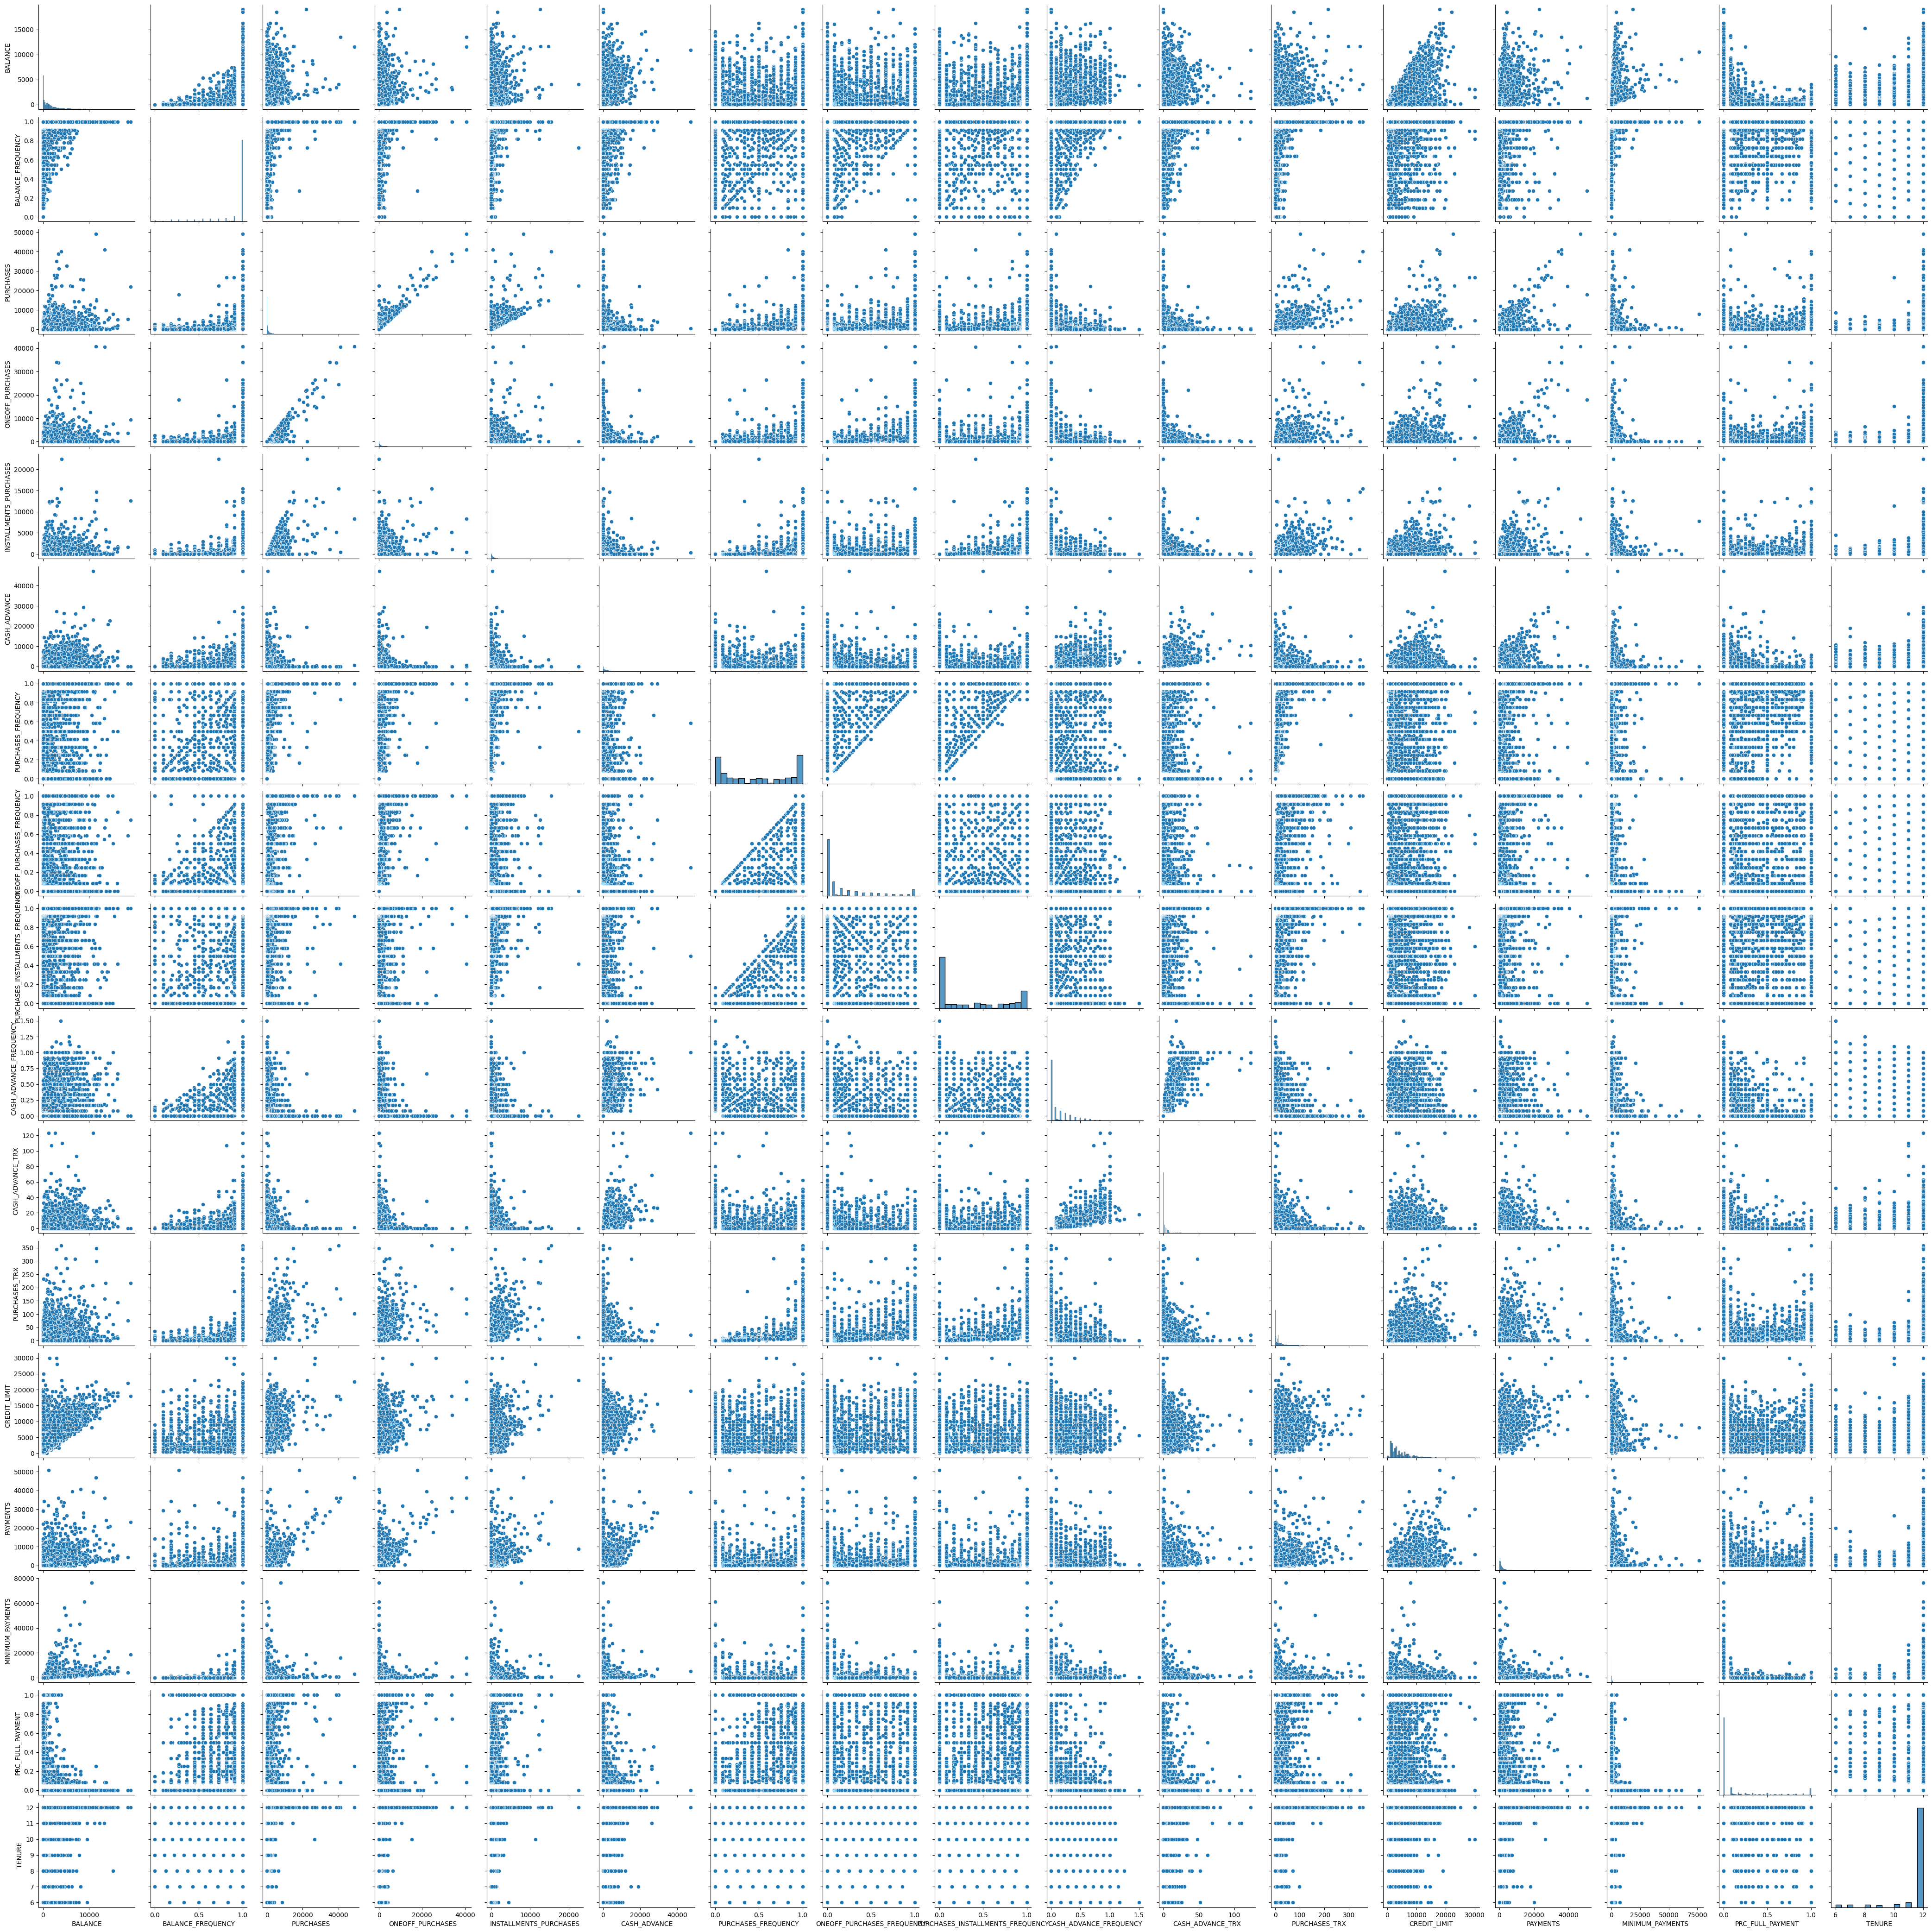

In [3]:
sns.pairplot(df)

analyza dat
pairploty

clustering KMeans

do pristi hodiny

In [5]:
df_clustering = df.copy()
if 'CUST_ID' in df_clustering.columns:
    df_clustering = df_clustering.drop(columns=['CUST_ID'])

nan_counts = df_clustering.isna().sum().sum()
print(f"Počet NaN v df_clustering: {nan_counts}")

df_truncated = df_clustering.dropna()

print(f"Počet řádků před: {len(df_clustering)}")
print(f"Počet řádků po odstranění NaN: {len(df_truncated)}")
print(f"Smazaných řádků: {len(df_clustering) - len(df_truncated)}")

df_truncated.head()

Počet NaN v df_clustering: 314
Počet řádků před: 8950
Počet řádků po odstranění NaN: 8636
Smazaných řádků: 314


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_truncated)

df_scaled = pd.DataFrame(df_scaled, columns=df_truncated.columns)

print(df_scaled.describe().T[['mean', 'std']].head(10))

df_scaled.head()

                                          mean       std
BALANCE                           0.000000e+00  1.000058
BALANCE_FREQUENCY                -3.422716e-16  1.000058
PURCHASES                         1.151876e-17  1.000058
ONEOFF_PURCHASES                 -3.291073e-17  1.000058
INSTALLMENTS_PURCHASES           -2.797412e-17  1.000058
CASH_ADVANCE                     -4.278395e-17  1.000058
PURCHASES_FREQUENCY               6.582147e-18  1.000058
ONEOFF_PURCHASES_FREQUENCY       -3.291073e-18  1.000058
PURCHASES_INSTALLMENTS_FREQUENCY  8.227683e-18  1.000058
CASH_ADVANCE_FREQUENCY            2.468305e-17  1.000058


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.744625,-0.370047,-0.429184,-0.359160,-0.354826,-0.468655,-0.820769,-0.686280,-0.717179,-0.681953,-0.479437,-0.517623,-0.962575,-0.543942,-0.305508,-0.537727,0.355181
1,0.764152,0.067679,-0.473208,-0.359160,-0.458839,2.568556,-1.236139,-0.686280,-0.926522,0.557022,0.099258,-0.597054,0.677204,0.796852,0.087689,0.212380,0.355181
2,0.426602,0.505405,-0.116413,0.099909,-0.458839,-0.468655,1.256077,2.646651,-0.926522,-0.681953,-0.479437,-0.120467,0.813852,-0.399503,-0.099906,-0.537727,0.355181
3,-0.373910,0.505405,-0.465825,-0.349660,-0.458839,-0.468655,-1.028455,-0.408536,-0.926522,-0.681953,-0.479437,-0.557339,-0.907916,-0.380165,-0.261131,-0.537727,0.355181
4,0.099551,0.505405,0.142062,-0.359160,0.994815,-0.468655,0.425339,-0.686280,0.538882,-0.681953,-0.479437,-0.279329,-0.743938,-0.132119,0.650363,-0.537727,0.355181


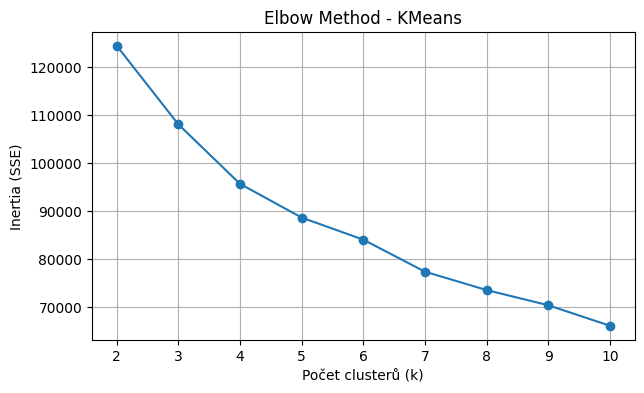

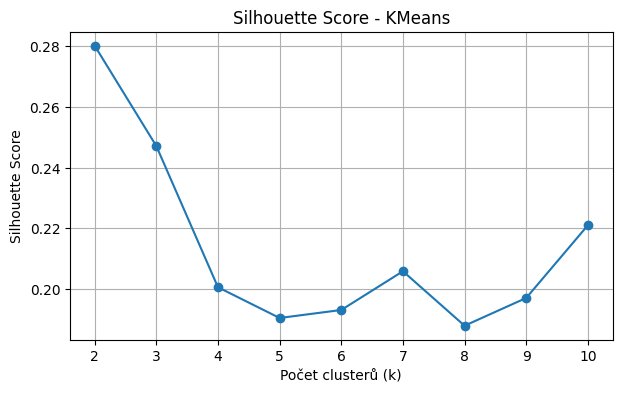

[np.float64(0.2802136700845037),
 np.float64(0.24709726016009056),
 np.float64(0.2004866872384794),
 np.float64(0.19034732611741967),
 np.float64(0.19298863107757958),
 np.float64(0.2057751923371526),
 np.float64(0.1877927146965203),
 np.float64(0.19695464945721827),
 np.float64(0.22094944666155059)]

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(2, 11)

inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)

    inertia_values.append(kmeans.inertia_)  # SSE pro Elbow
    silhouette_values.append(silhouette_score(df_scaled, labels))


plt.figure(figsize=(7, 4))
plt.plot(k_values, inertia_values, marker='o')
plt.title("Elbow Method - KMeans")
plt.xlabel("Počet clusterů (k)")
plt.ylabel("Inertia (SSE)")
plt.xticks(k_values)
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(k_values, silhouette_values, marker='o')
plt.title("Silhouette Score - KMeans")
plt.xlabel("Počet clusterů (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)
plt.show()

silhouette_values


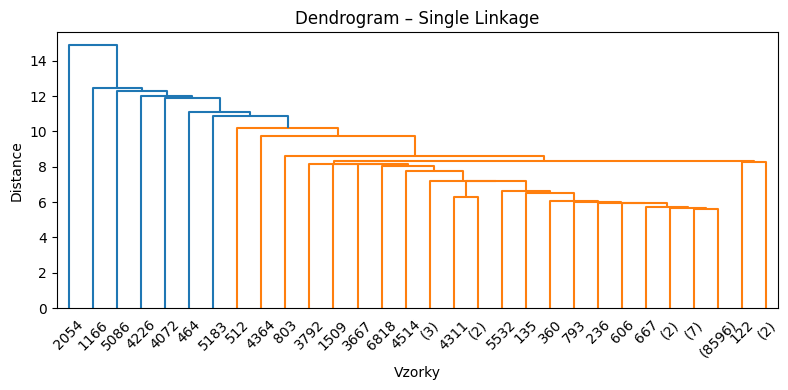

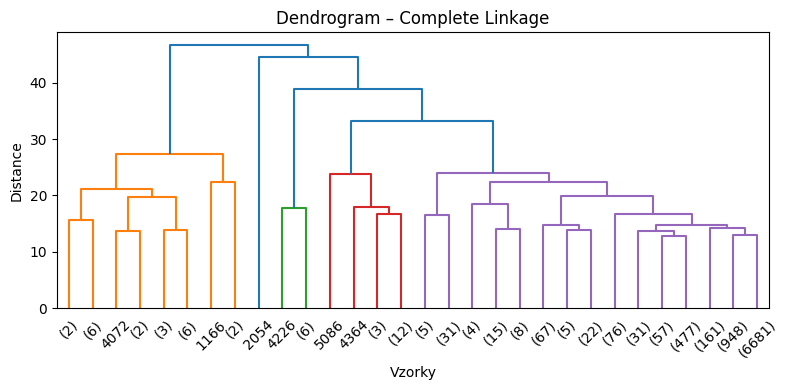

In [10]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

k = 3
kmeans = KMeans(n_clusters=k, random_state=13)
kmeans_labels = kmeans.fit_predict(df_scaled)


plt.figure(figsize=(8, 4))
Z_single = linkage(df_scaled, method='single')
dendrogram(Z_single, truncate_mode='lastp', p=30) # Truncate the dendrogram
plt.title("Dendrogram – Single Linkage")
plt.xlabel("Vzorky")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
Z_complete = linkage(df_scaled, method='complete')
dendrogram(Z_complete, truncate_mode='lastp', p=30) # Truncate the dendrogram
plt.title("Dendrogram – Complete Linkage")
plt.xlabel("Vzorky")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

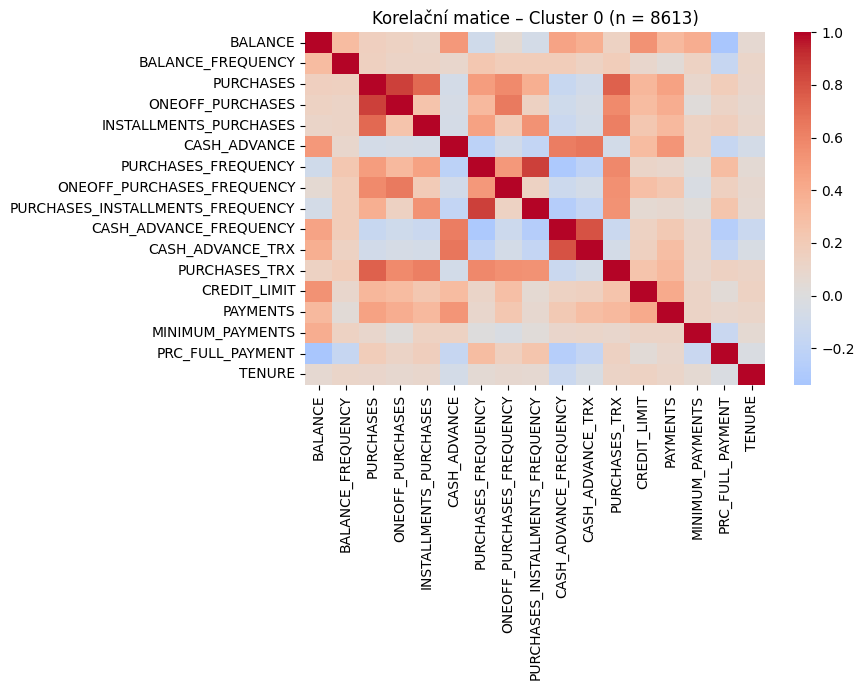

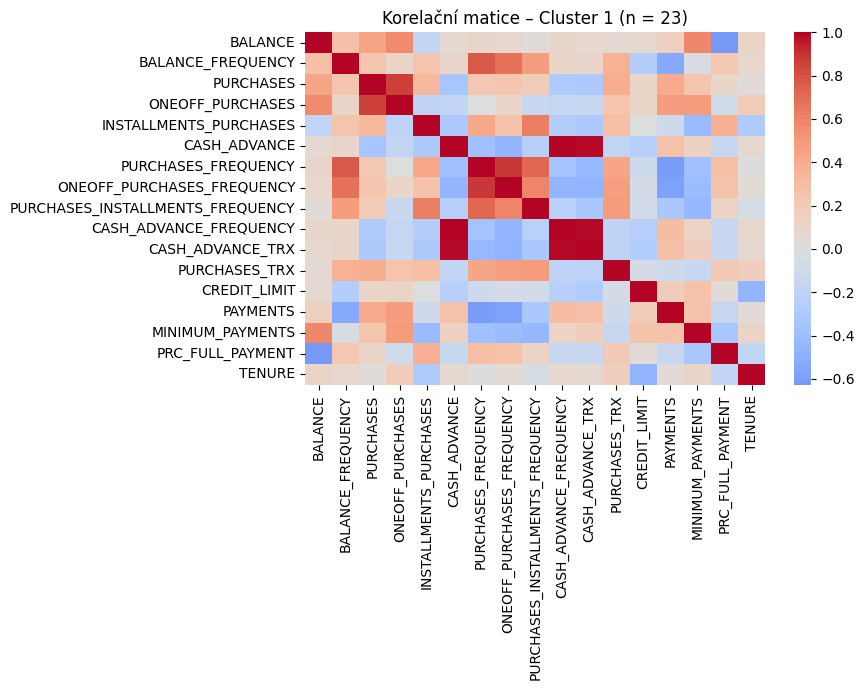

In [14]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- CLUSTERING ---
agg3 = AgglomerativeClustering(n_clusters=2, linkage='complete')
cluster_labels_3 = agg3.fit_predict(df_scaled)

df_scaled['Cluster'] = cluster_labels_3

# --- CORRELATION HEATMAPS BY CLUSTER ---
clusters = sorted(df_scaled['Cluster'].unique())

for cl in clusters:
    cluster_data = df_scaled[df_scaled['Cluster'] == cl].drop(columns=['Cluster'])
    corr = cluster_data.corr()

    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
    plt.title(f"Korelační matice – Cluster {cl} (n = {len(cluster_data)})")
    plt.tight_layout()
    plt.show()


In [16]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.03, random_state=42)
outlier_labels = iso.fit_predict(df_scaled)

# -1 = outlier
df_no_outliers = df_scaled[outlier_labels == 1].copy()

print("Původní dataset:", df_scaled.shape)
print("Bez outlierů:", df_no_outliers.shape)

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()
df_transformed = pt.fit_transform(df_no_outliers)

df_transformed = pd.DataFrame(df_transformed, columns=df_no_outliers.columns)

Původní dataset: (8636, 18)
Bez outlierů: (8376, 18)


In [18]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()
df_transformed = pt.fit_transform(df_no_outliers)

df_transformed = pd.DataFrame(df_transformed, columns=df_no_outliers.columns)


from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels_agg = agg.fit_predict(df_transformed)
df_transformed['Cluster'] = labels_agg

df_transformed['Cluster'].value_counts()


,count
Cluster,
0,5087
1,2264
2,1025


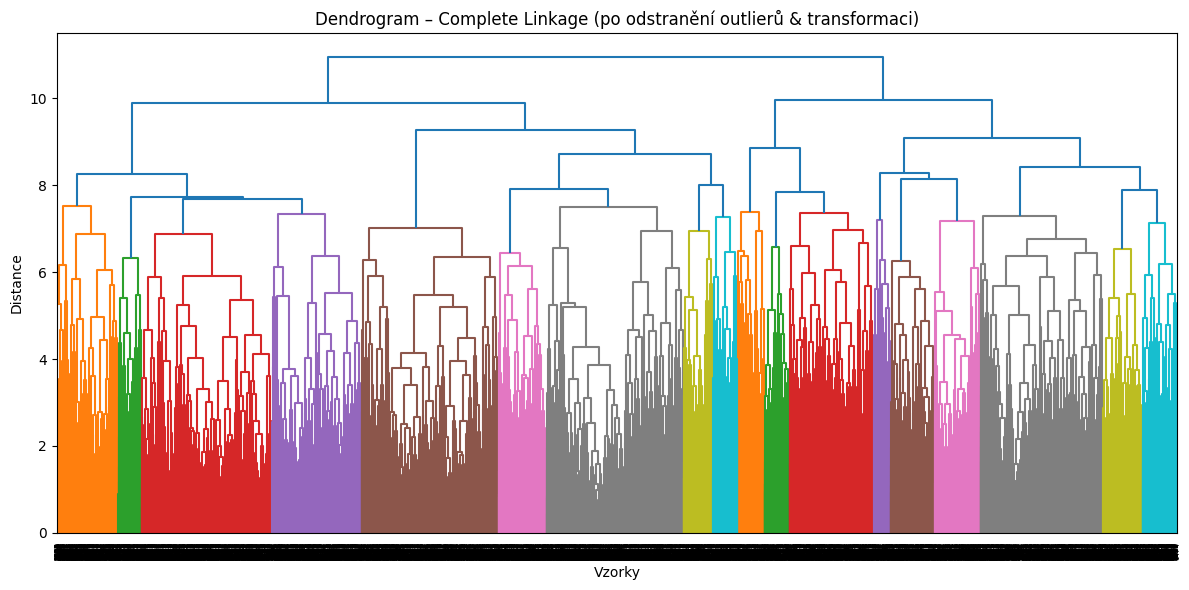

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Zajistíme, že sloupec Cluster nebude v datech pro linkage
df_for_dendro = df_transformed.drop(columns=['Cluster'])

# Vytvoření hierarchical linkage matice
Z_complete = linkage(df_for_dendro, method='complete')

# Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z_complete,
           truncate_mode='level',  # přehlednější řez (můžeš vypnout)
           p=30,                   # kolik posledních merges chceme vidět
           leaf_rotation=90)
plt.title("Dendrogram – Complete Linkage (po odstranění outlierů & transformaci)")
plt.xlabel("Vzorky")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


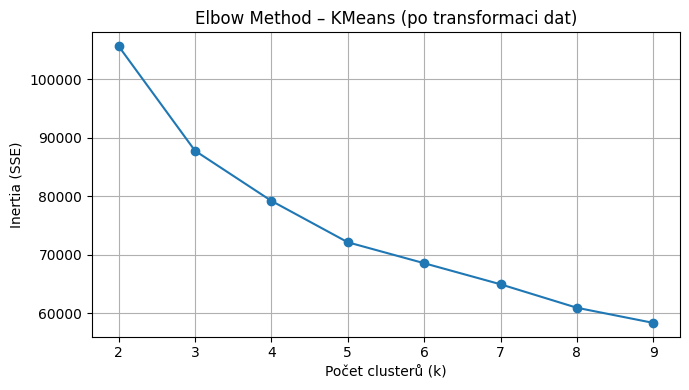

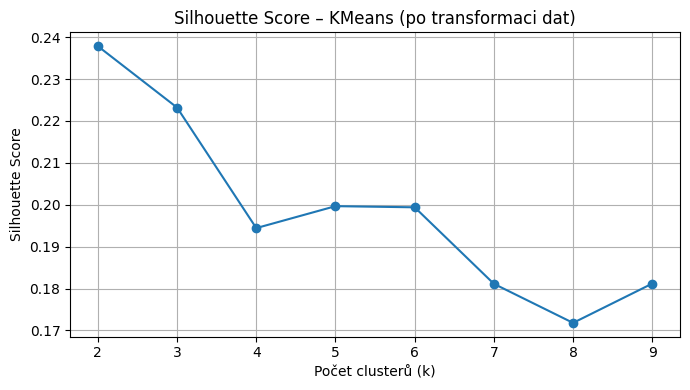

Silhouette values: {2: np.float64(0.23786205747612912), 3: np.float64(0.22320127024893785), 4: np.float64(0.19442943755932543), 5: np.float64(0.19966508163907817), 6: np.float64(0.1993909109006154), 7: np.float64(0.18112424887187312), 8: np.float64(0.17179769194214775), 9: np.float64(0.1811843016252147)}


In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X = df_for_dendro  # data bez cluster sloupce

k_values = range(2, 10)
inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X, labels))


plt.figure(figsize=(7, 4))
plt.plot(k_values, inertia_values, marker='o')
plt.title("Elbow Method – KMeans (po transformaci dat)")
plt.xlabel("Počet clusterů (k)")
plt.ylabel("Inertia (SSE)")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(k_values, silhouette_values, marker='o')
plt.title("Silhouette Score – KMeans (po transformaci dat)")
plt.xlabel("Počet clusterů (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Silhouette values:", dict(zip(k_values, silhouette_values)))


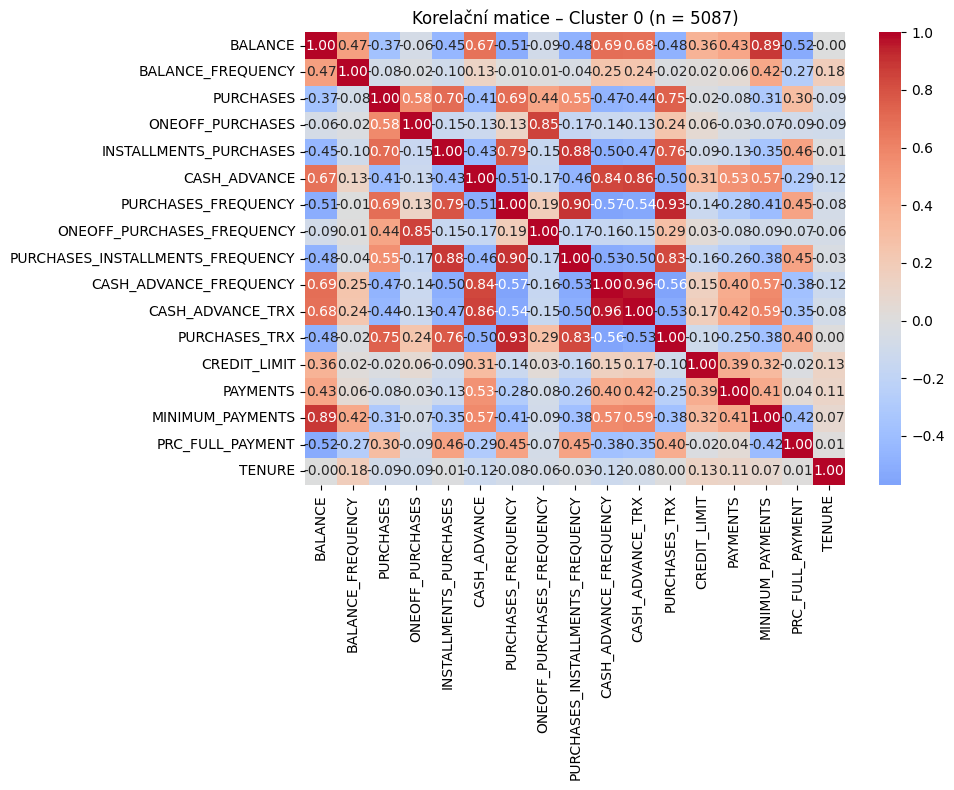

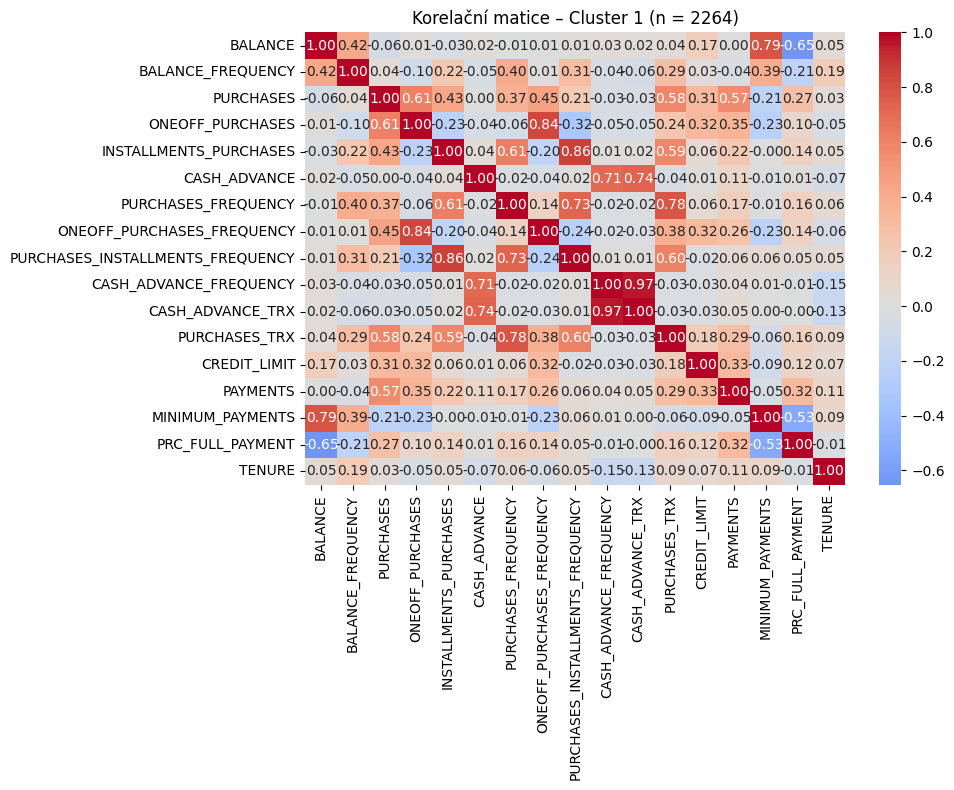

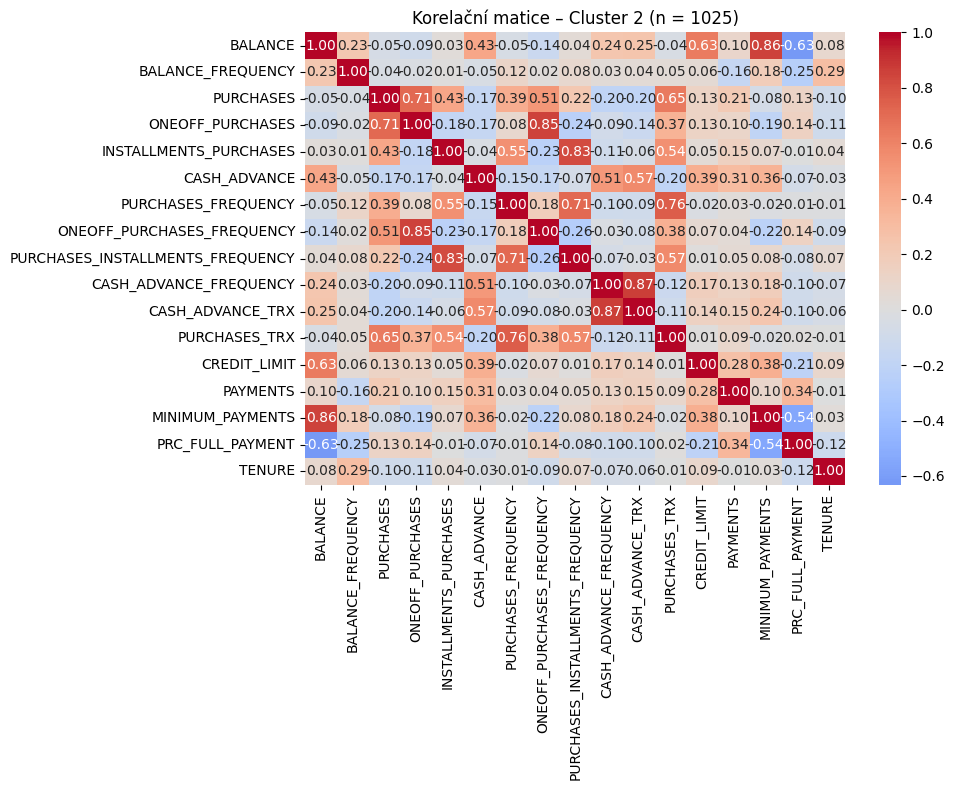

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

features = [c for c in df_transformed.columns if c != "Cluster"]
clusters = sorted(df_transformed["Cluster"].unique())

for cl in clusters:
    data_cl = df_transformed[df_transformed["Cluster"] == cl][features]
    n = len(data_cl)

    if n < 2:
        plt.figure(figsize=(7, 2))
        plt.text(0.5, 0.5, f"Cluster {cl}: n = {n} → nelze spočítat korelace",
                 ha="center", va="center", fontsize=14)
        plt.axis("off")
        plt.show()
        continue

    corr = data_cl.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=False,
        cbar=True
    )
    plt.title(f"Korelační matice – Cluster {cl} (n = {n})")
    plt.tight_layout()
    plt.show()


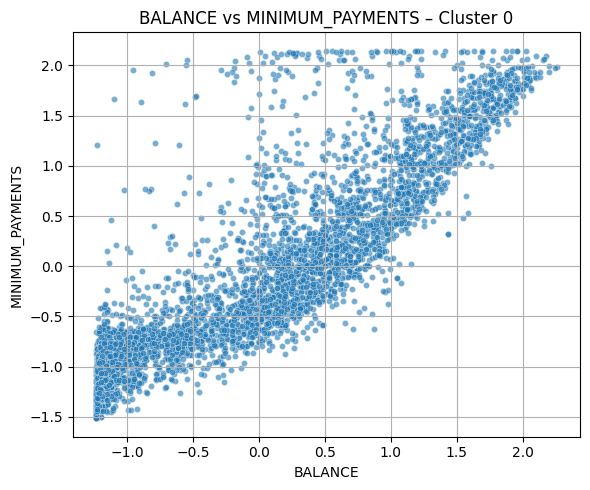

Vyšší zůstatek → vyšší minimální splátka (logické navázání částky) (Cluster 0)



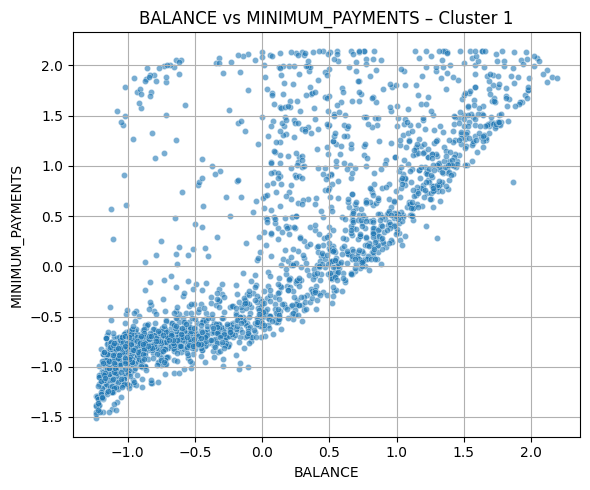

Vyšší zůstatek → vyšší minimální splátka (logické navázání částky) (Cluster 1)



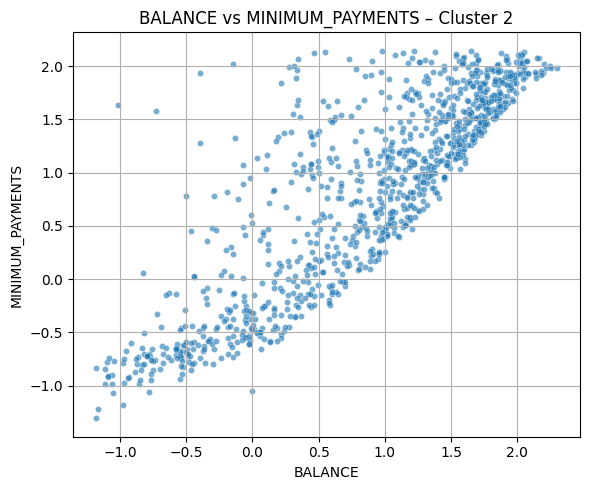

Vyšší zůstatek → vyšší minimální splátka (logické navázání částky) (Cluster 2)



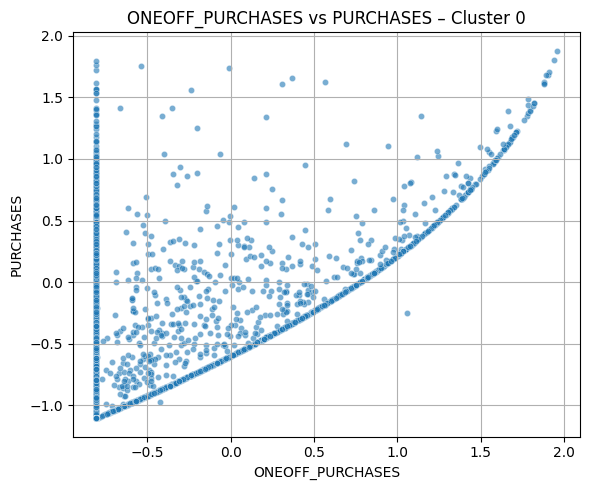

Jednorázové nákupy tvoří výraznou část celkových nákupů (Cluster 0)



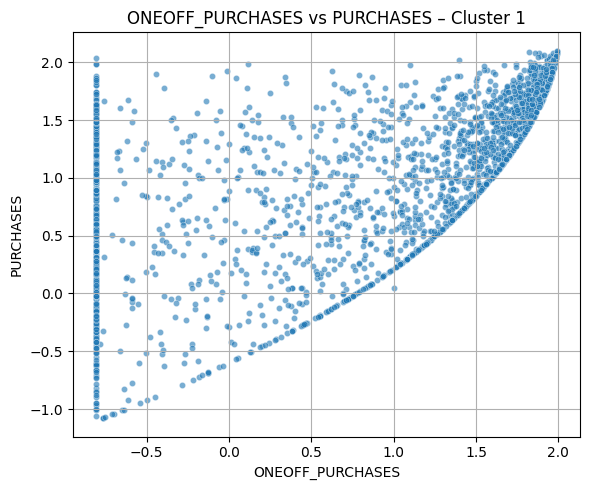

Jednorázové nákupy tvoří výraznou část celkových nákupů (Cluster 1)



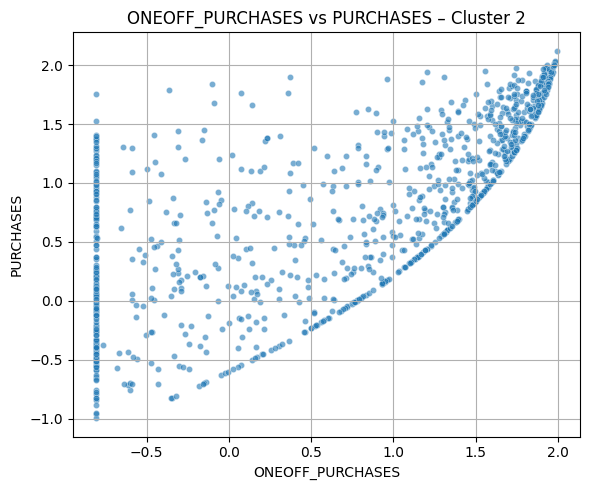

Jednorázové nákupy tvoří výraznou část celkových nákupů (Cluster 2)



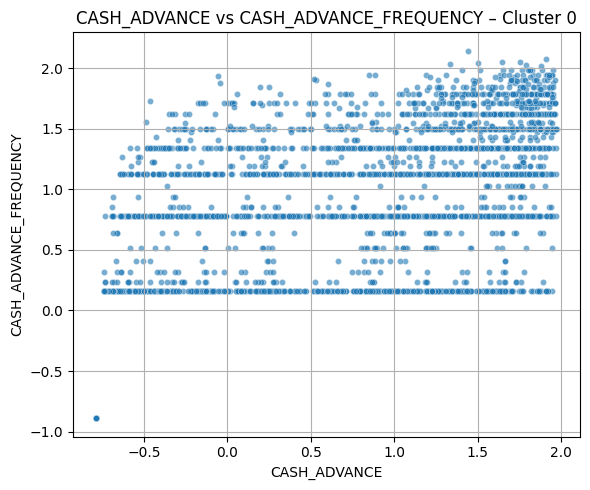

Častější cash-advance → vyšší objem vybraných peněz (Cluster 0)



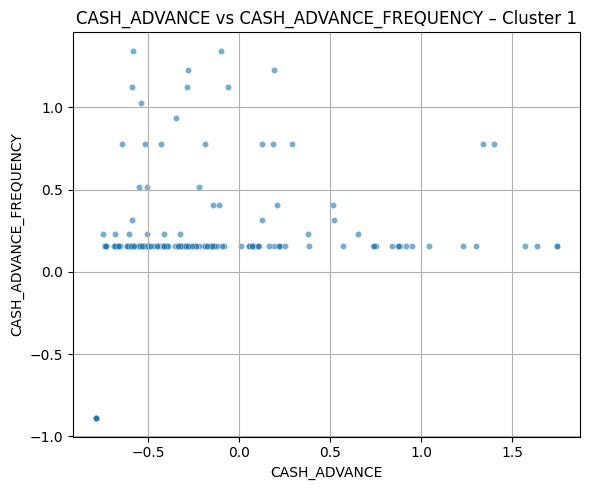

Častější cash-advance → vyšší objem vybraných peněz (Cluster 1)



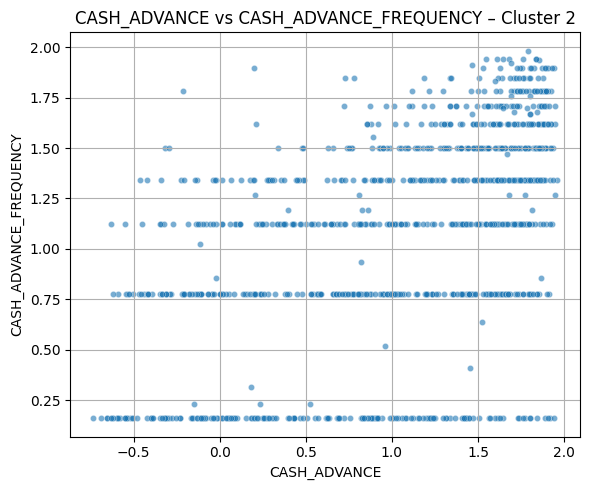

Častější cash-advance → vyšší objem vybraných peněz (Cluster 2)



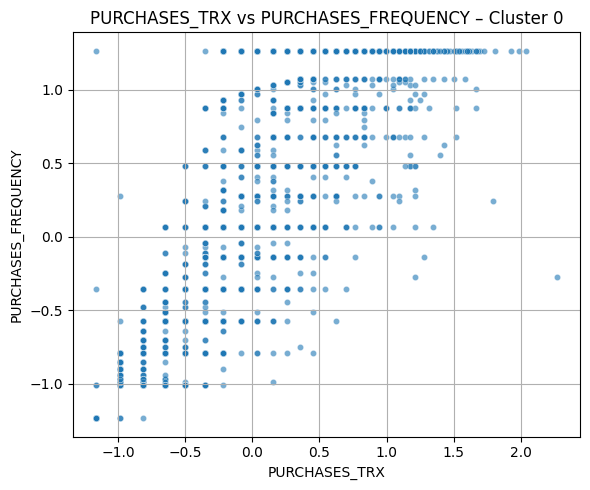

Častější nakupování → více nákupních transakcí (Cluster 0)



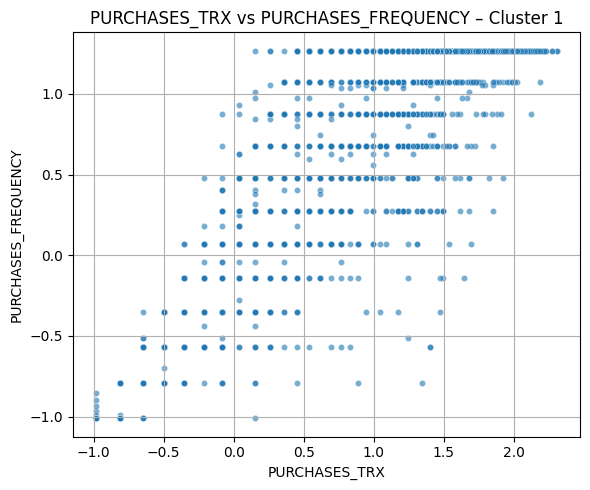

Častější nakupování → více nákupních transakcí (Cluster 1)



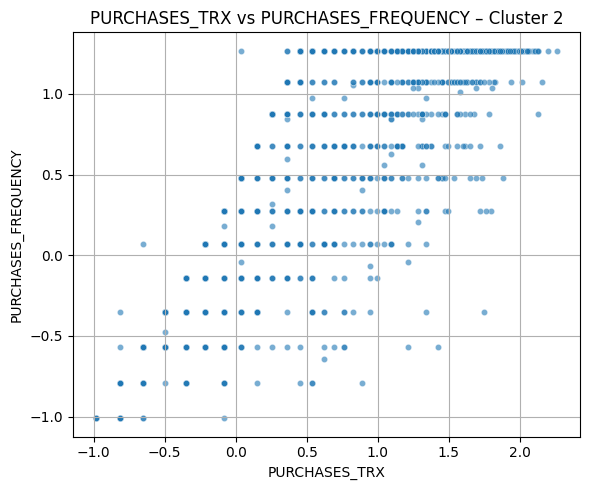

Častější nakupování → více nákupních transakcí (Cluster 2)



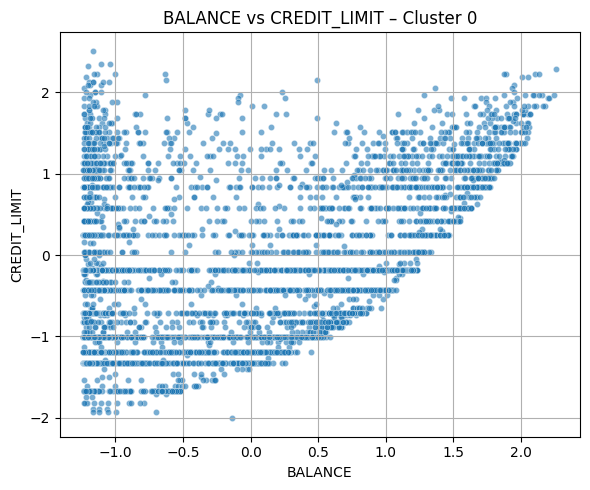

Vyšší zůstatek → větší úvěr (Cluster 0)



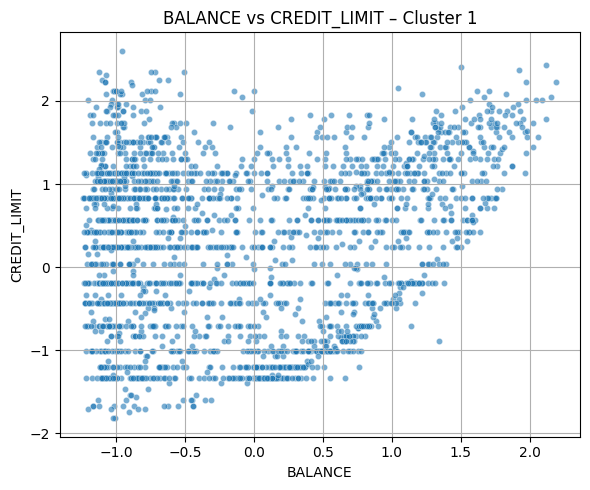

Vyšší zůstatek → větší úvěr (Cluster 1)



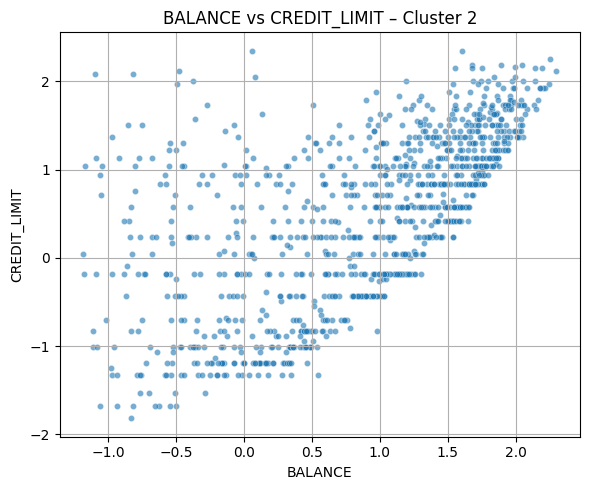

Vyšší zůstatek → větší úvěr (Cluster 2)



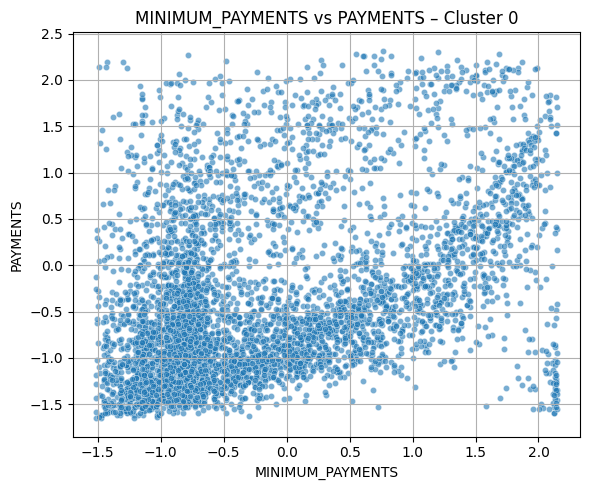

Uživatelé, co mají malé platby → mají menší celkové platby (Cluster 0)



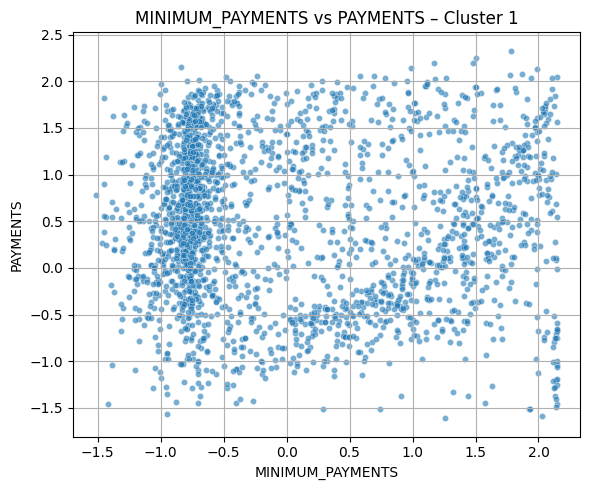

Uživatelé, co mají malé platby → mají menší celkové platby (Cluster 1)



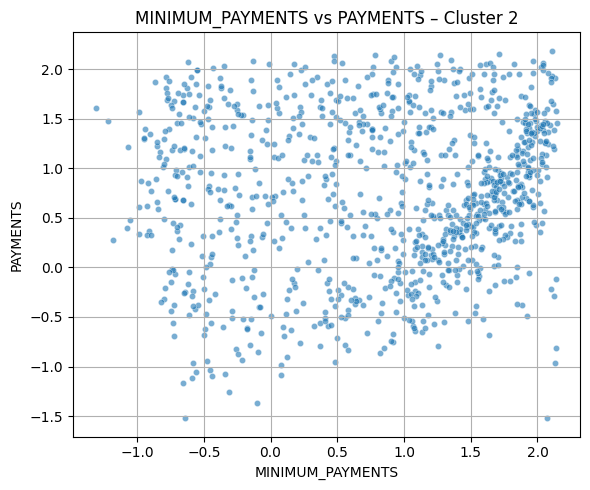

Uživatelé, co mají malé platby → mají menší celkové platby (Cluster 2)



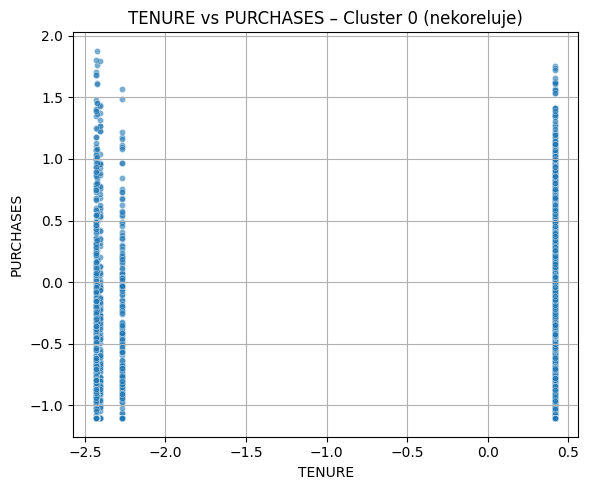

Délka vlastnictví karty nemá souvislost s objemem nákupů (Cluster 0)



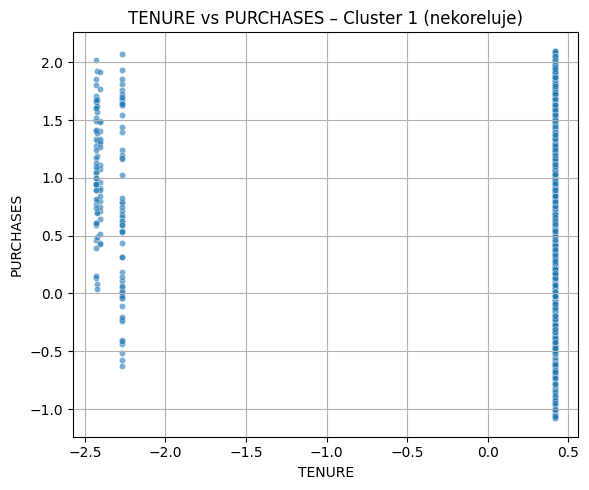

Délka vlastnictví karty nemá souvislost s objemem nákupů (Cluster 1)



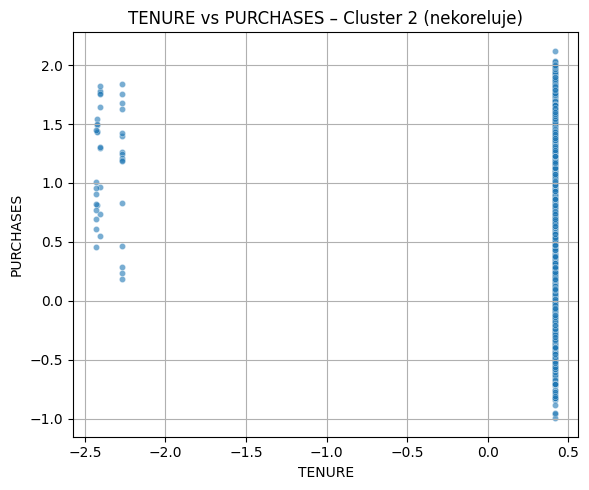

Délka vlastnictví karty nemá souvislost s objemem nákupů (Cluster 2)



In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

relationships = [
    ("BALANCE", "MINIMUM_PAYMENTS",
     "Vyšší zůstatek → vyšší minimální splátka (logické navázání částky)"),

    ("ONEOFF_PURCHASES", "PURCHASES",
     "Jednorázové nákupy tvoří výraznou část celkových nákupů"),

    ("CASH_ADVANCE", "CASH_ADVANCE_FREQUENCY",
     "Častější cash-advance → vyšší objem vybraných peněz"),

    ("PURCHASES_TRX", "PURCHASES_FREQUENCY",
     "Častější nakupování → více nákupních transakcí"),

    ("BALANCE", "CREDIT_LIMIT",
     "Vyšší zůstatek → větší úvěr"),

    ("MINIMUM_PAYMENTS", "PAYMENTS",
     "Uživatelé, co mají malé platby → mají menší celkové platby"),
]


non_relationship = (
    "TENURE", "PURCHASES",
    "Délka vlastnictví karty nemá souvislost s objemem nákupů"
)

for x, y, comment in relationships:
    for cl in sorted(df_transformed['Cluster'].unique()):
        cl_data = df_transformed[df_transformed['Cluster'] == cl]

        plt.figure(figsize=(6, 5))
        sns.scatterplot(data=cl_data, x=x, y=y, s=20, alpha=0.6)
        plt.title(f"{x} vs {y} – Cluster {cl}")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        print(f"{comment} (Cluster {cl})\n")


x, y, comment = non_relationship

for cl in sorted(df_transformed['Cluster'].unique()):
    cl_data = df_transformed[df_transformed['Cluster'] == cl]

    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=cl_data, x=x, y=y, s=20, alpha=0.6)
    plt.title(f"{x} vs {y} – Cluster {cl} (nekoreluje)")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"{comment} (Cluster {cl})\n")



-----------------------------------------------TEST-------------------------------------------------------


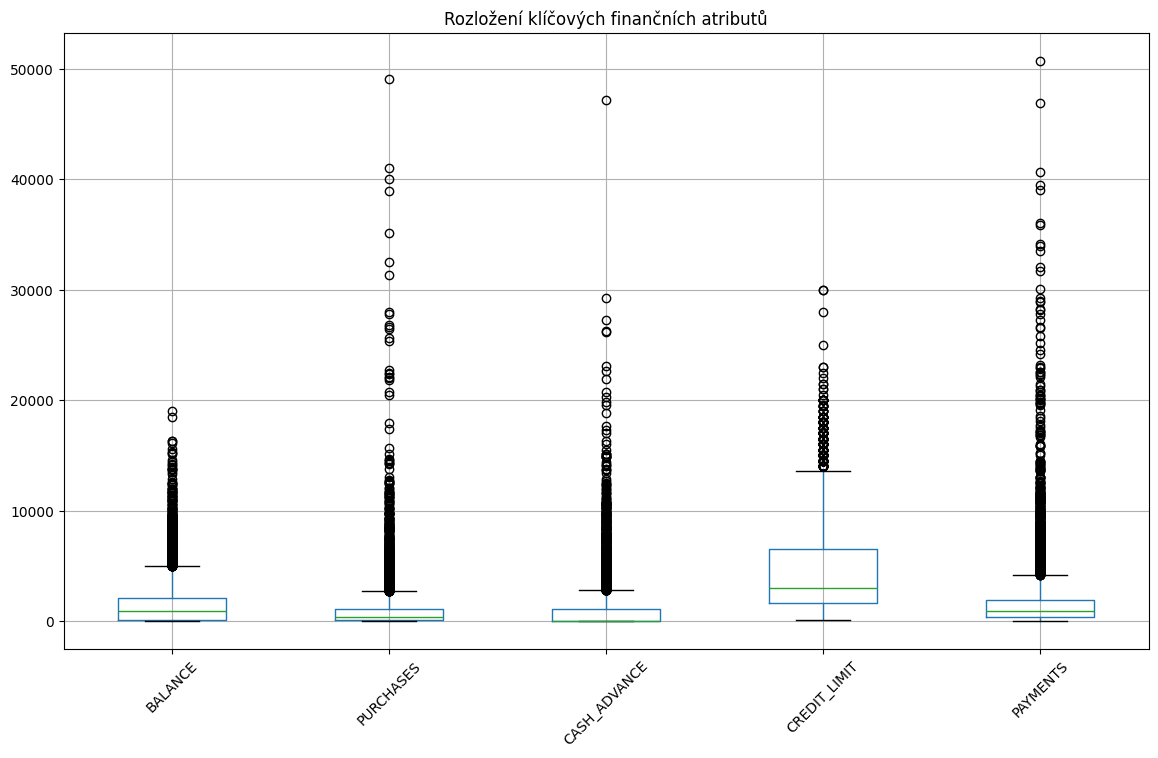

In [6]:
important_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

plt.figure(figsize=(14,8))
df[important_cols].boxplot()
plt.title("Rozložení klíčových finančních atributů")
plt.xticks(rotation=45)
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

important_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

X = df[important_cols].copy()

# Impute missing values with the mean
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

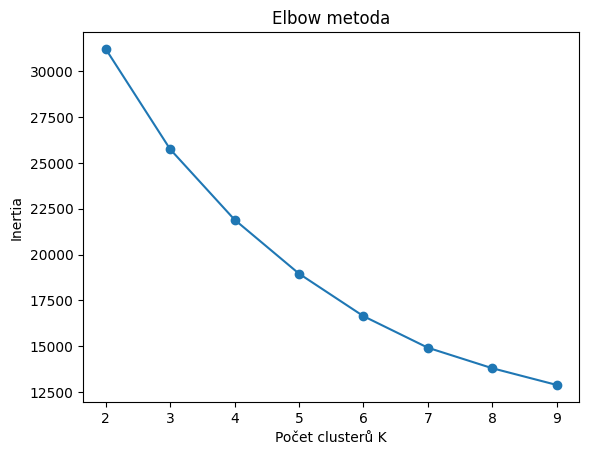

In [15]:
from sklearn.cluster import KMeans

inertia = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=13, n_init=10) # Added n_init
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Počet clusterů K")
plt.ylabel("Inertia")
plt.title("Elbow metoda")
plt.show()

In [17]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    print(f"K={k} → Silhouette: {score:.3f}")

K=2 → Silhouette: 0.566
K=3 → Silhouette: 0.512
K=4 → Silhouette: 0.404
K=5 → Silhouette: 0.410
K=6 → Silhouette: 0.405
K=7 → Silhouette: 0.385
K=8 → Silhouette: 0.395
K=9 → Silhouette: 0.389


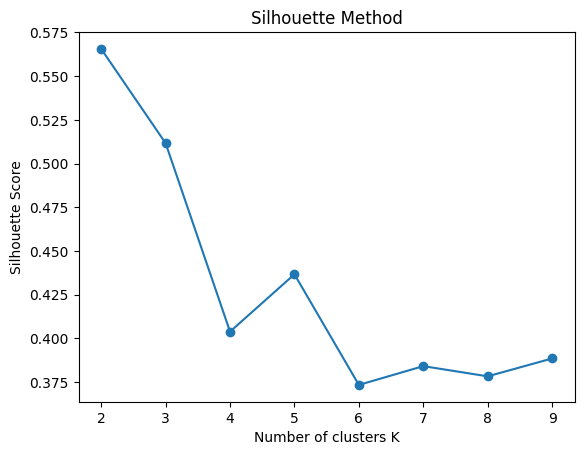

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(score)

plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

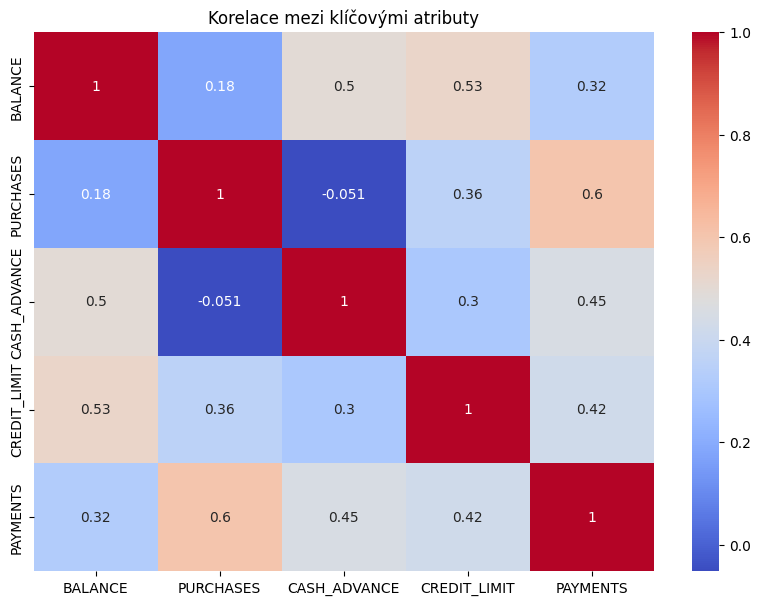

In [23]:
plt.figure(figsize=(10,7))
sns.heatmap(df[important_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Korelace mezi klíčovými atributy")
plt.show()


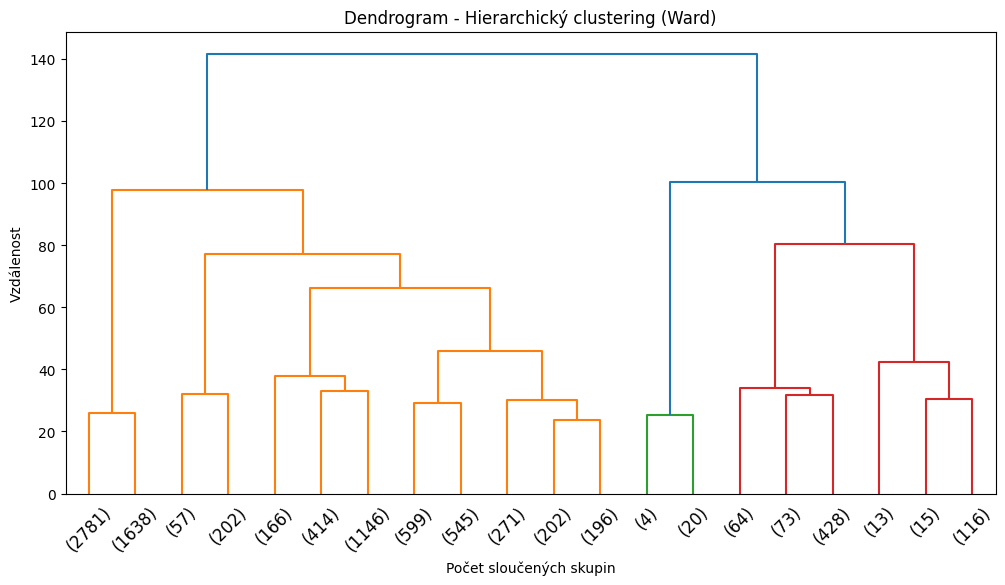

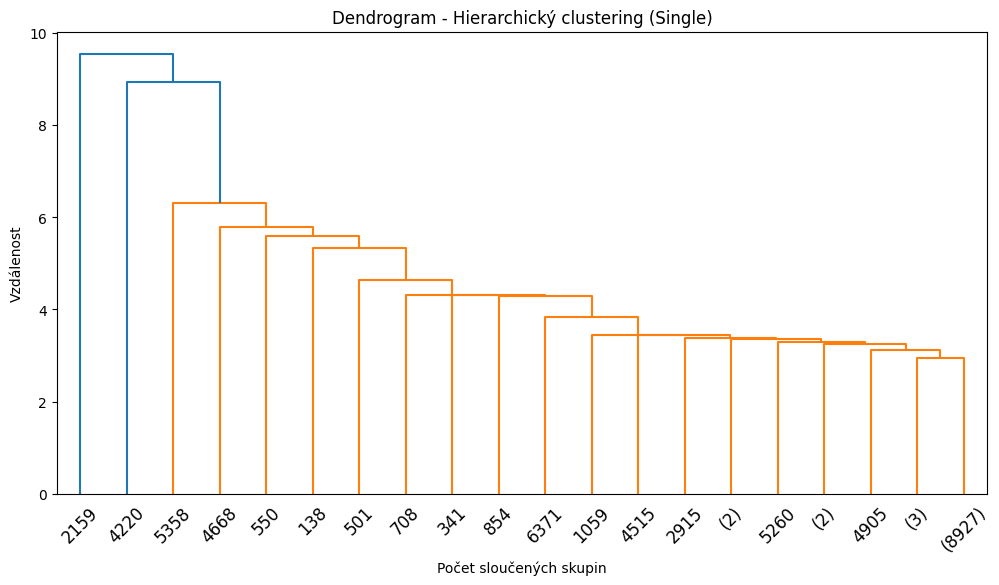

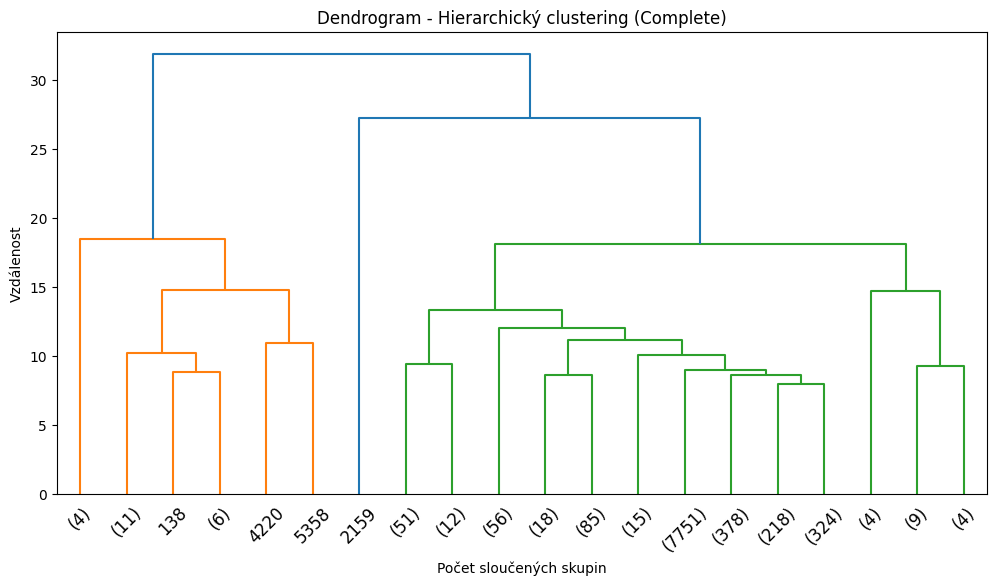

In [26]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np

important_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

X = df[important_cols].copy()

# Impute missing values with the mean
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Ward linkage
linked_ward = linkage(X_scaled, method='ward')
plt.figure(figsize=(12,6))
dendrogram(linked_ward, truncate_mode="lastp", p=20, leaf_rotation=45)
plt.title("Dendrogram - Hierarchický clustering (Ward)")
plt.xlabel("Počet sloučených skupin")
plt.ylabel("Vzdálenost")
plt.show()

# Single linkage
linked_single = linkage(X_scaled, method='single')
plt.figure(figsize=(12,6))
dendrogram(linked_single, truncate_mode="lastp", p=20, leaf_rotation=45)
plt.title("Dendrogram - Hierarchický clustering (Single)")
plt.xlabel("Počet sloučených skupin")
plt.ylabel("Vzdálenost")
plt.show()

# Complete linkage
linked_complete = linkage(X_scaled, method='complete')
plt.figure(figsize=(12,6))
dendrogram(linked_complete, truncate_mode="lastp", p=20, leaf_rotation=45)
plt.title("Dendrogram - Hierarchický clustering (Complete)")
plt.xlabel("Počet sloučených skupin")
plt.ylabel("Vzdálenost")
plt.show()

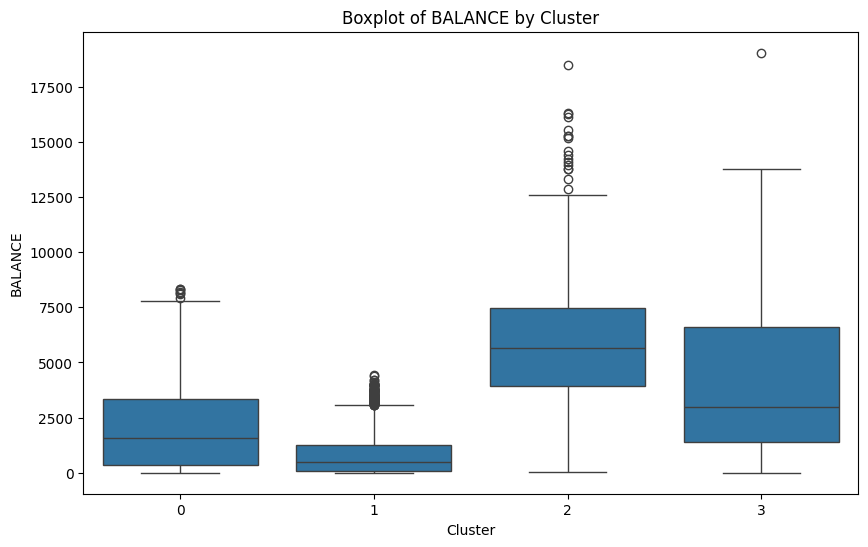

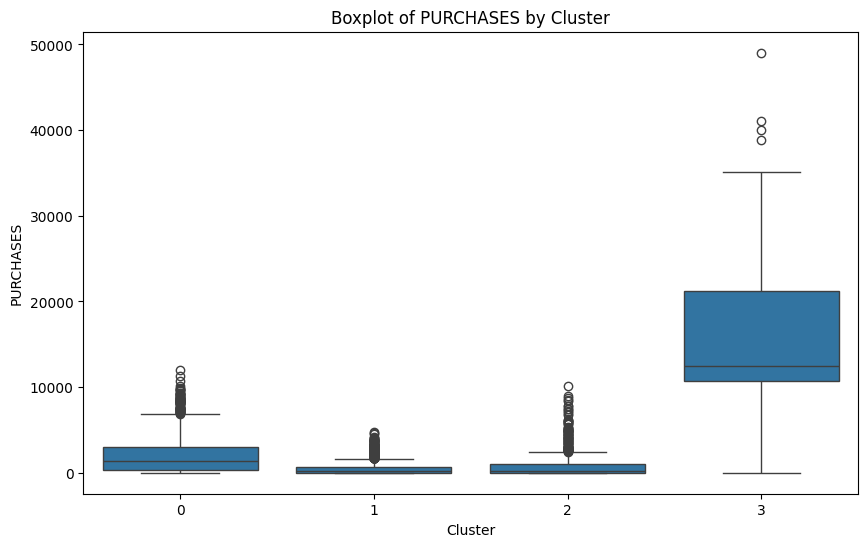

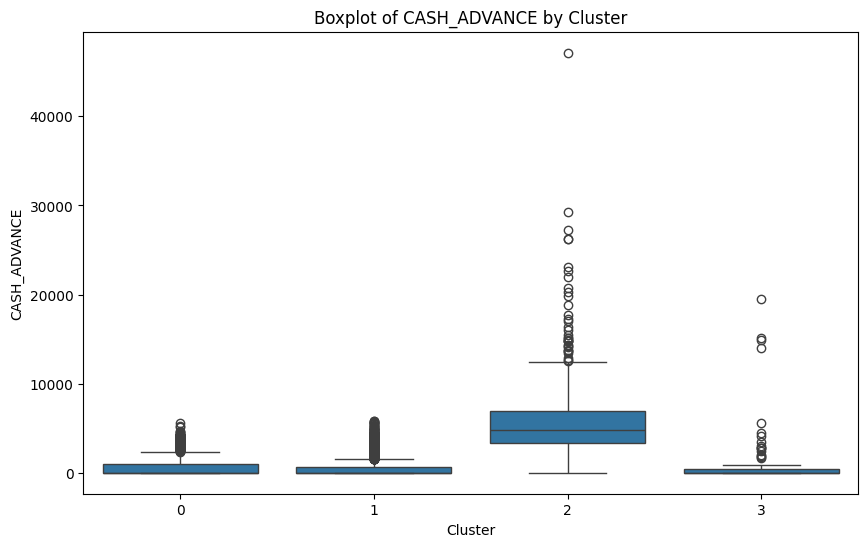

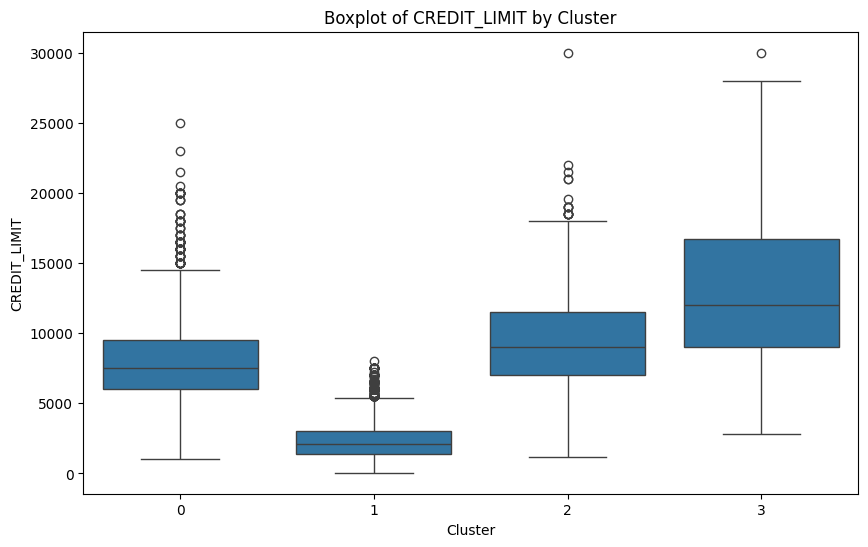

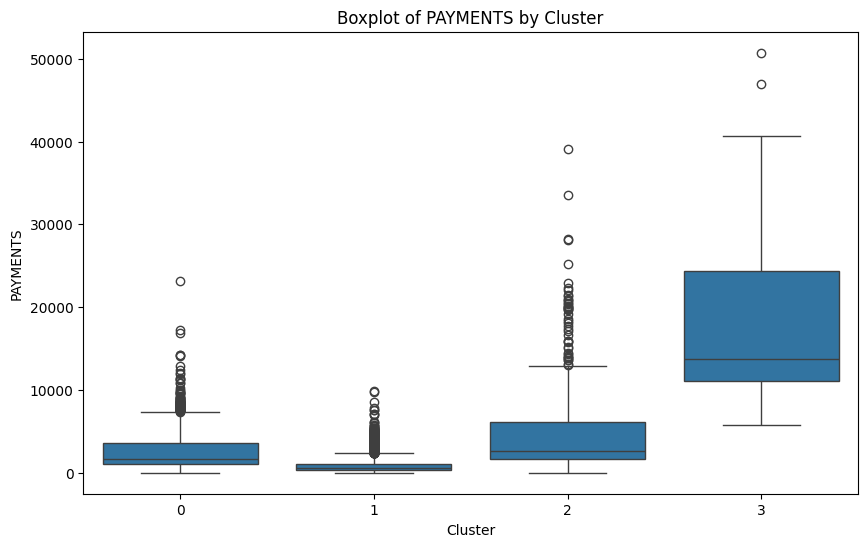

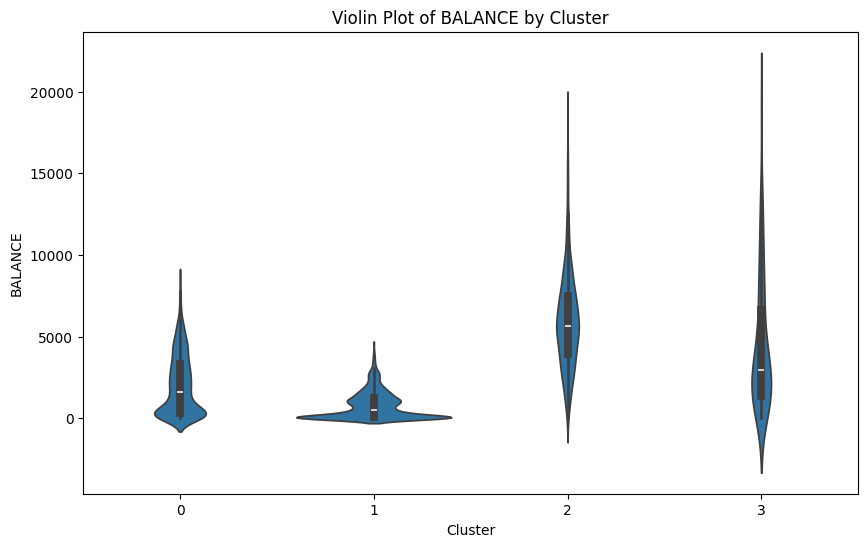

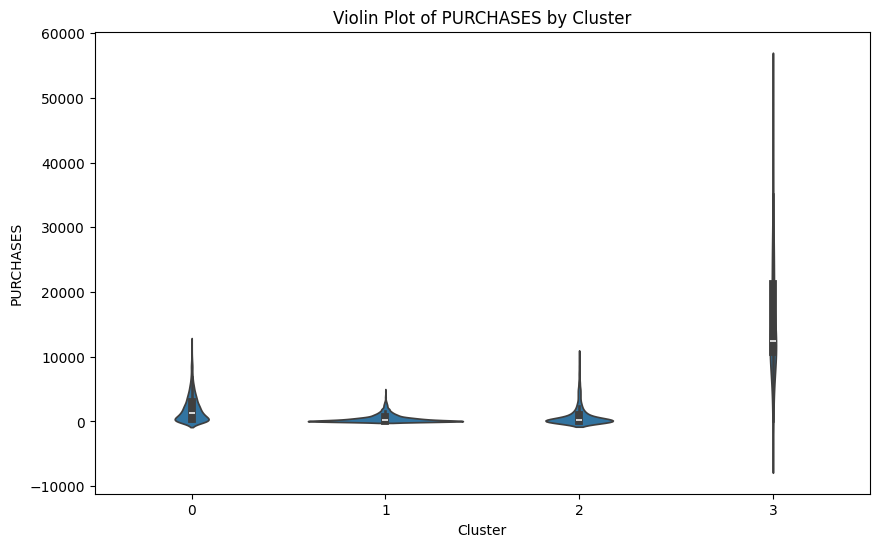

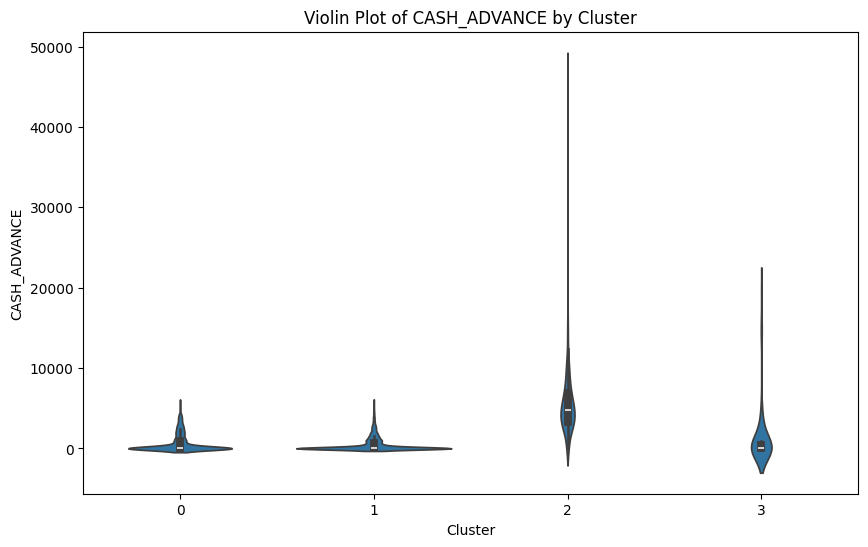

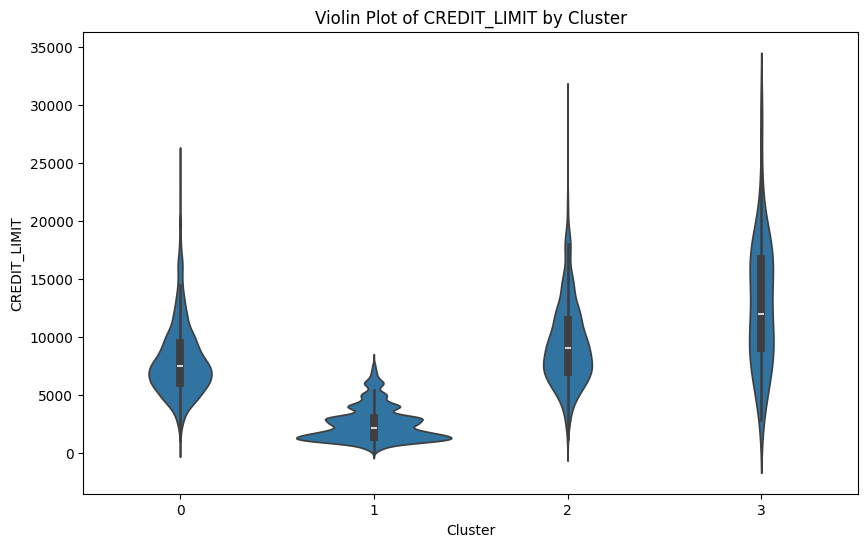

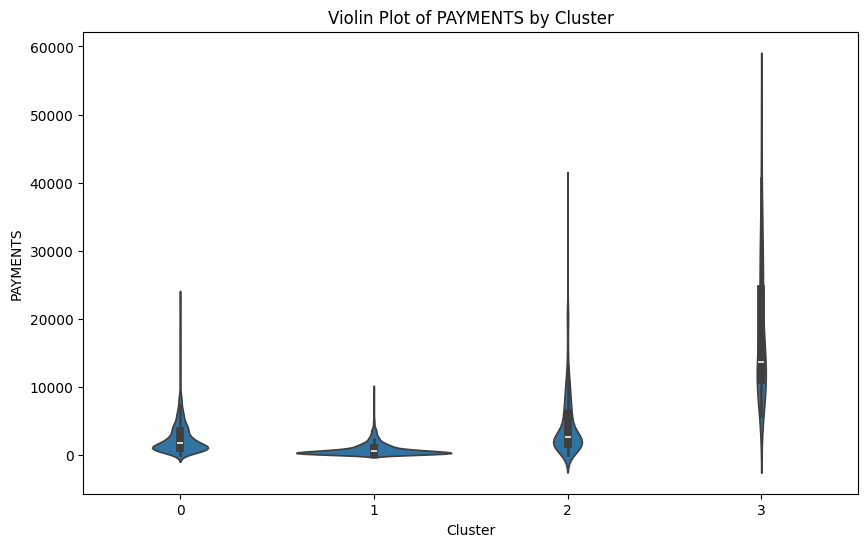

In [29]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Choose the number of clusters based on the elbow and silhouette plots
n_clusters = 4

# Fit KMeans to the scaled data
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
km.fit(X_scaled)

# Add cluster labels to the original DataFrame
df['Cluster'] = km.labels_

# Analyze cluster characteristics with boxplots
important_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

for col in important_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cluster', y=col, data=df)
    plt.title(f'Boxplot of {col} by Cluster')
    plt.show()

# Analyze cluster characteristics with violin plots
for col in important_cols:
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Cluster', y=col, data=df)
    plt.title(f'Violin Plot of {col} by Cluster')
    plt.show()

Let's visualize the correlation matrix for each cluster using a heatmap to see the relationships between the financial attributes within each group.

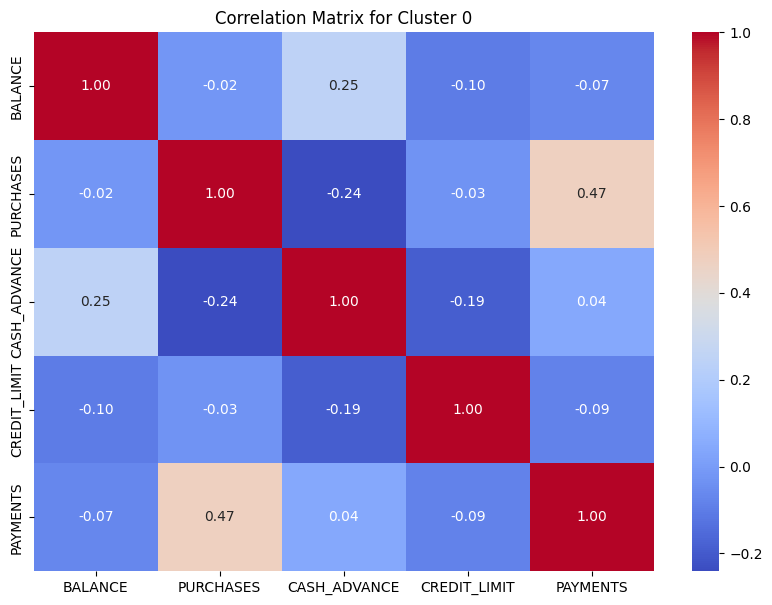

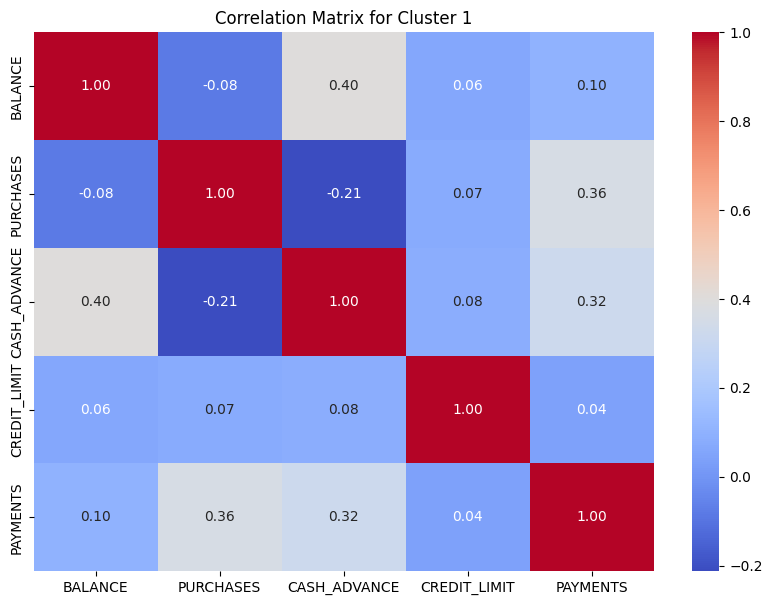

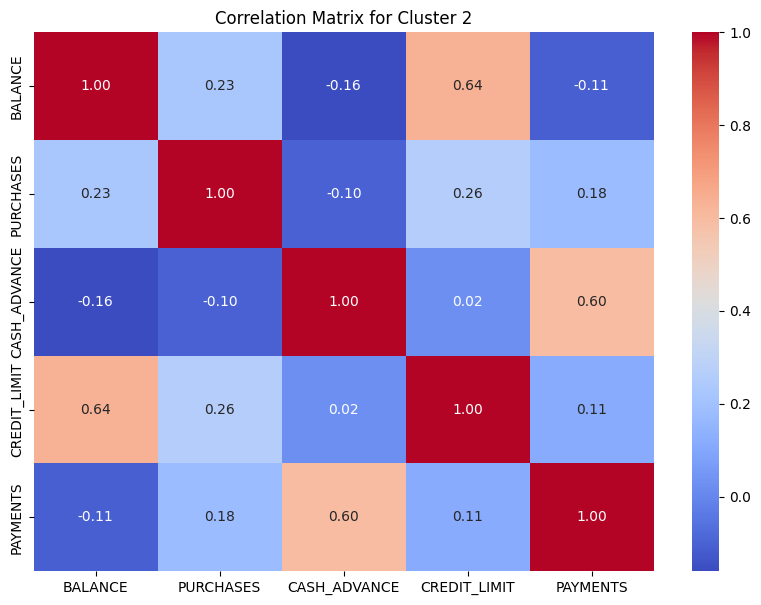

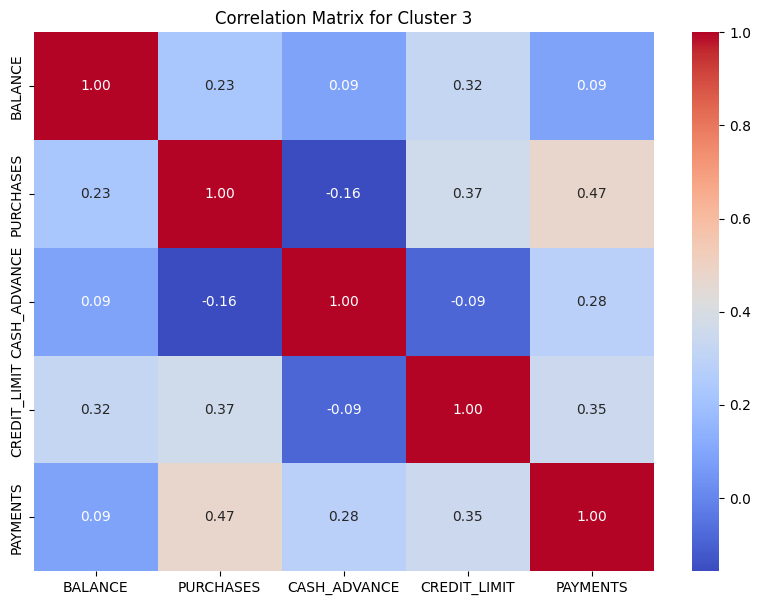

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group data by cluster and calculate the correlation matrix for each cluster
for cluster_id in sorted(df['Cluster'].unique()):
    cluster_df = df[df['Cluster'] == cluster_id]
    plt.figure(figsize=(10, 7))
    sns.heatmap(cluster_df[important_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Matrix for Cluster {cluster_id}')
    plt.show()

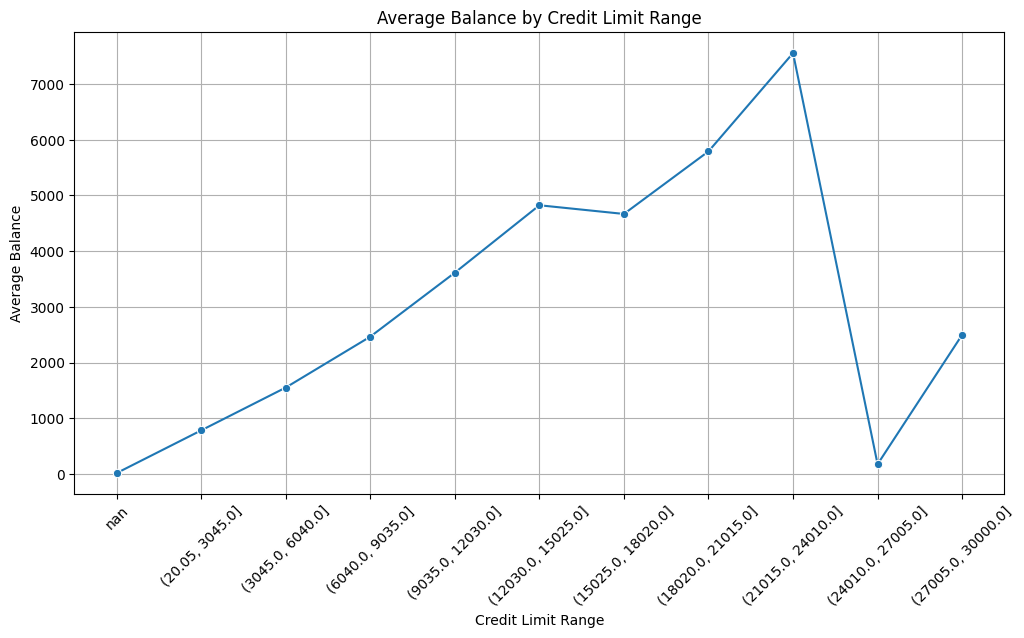

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

# Create bins for Credit Limit to group the data
df['Credit_Limit_Bins'] = pd.cut(df['CREDIT_LIMIT'], bins=10).astype(str) # Convert bins to string

# Group by Credit Limit Bins and calculate the mean Balance
credit_balance_trend = df.groupby('Credit_Limit_Bins')['BALANCE'].mean().reset_index()

# Sort the bins for a meaningful line plot (sorting strings might not be perfect, but better than unsorted)
# A more robust sorting would involve sorting by the bin intervals themselves before converting to string
# For simplicity here, we'll rely on pandas default sorting of string representation if possible or skip sorting if it causes issues.
# Let's sort by the left boundary of the interval for better ordering and handle 'nan'
credit_balance_trend['Sort_Key'] = credit_balance_trend['Credit_Limit_Bins'].apply(lambda x: float(x.split(', ')[0][1:]) if x != 'nan' else -1) # Assign a value that ensures 'nan' is sorted first or last
credit_balance_trend = credit_balance_trend.sort_values(by='Sort_Key').drop('Sort_Key', axis=1)


# Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='Credit_Limit_Bins', y='BALANCE', data=credit_balance_trend, marker='o')
plt.title('Average Balance by Credit Limit Range')
plt.xlabel('Credit Limit Range')
plt.ylabel('Average Balance')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

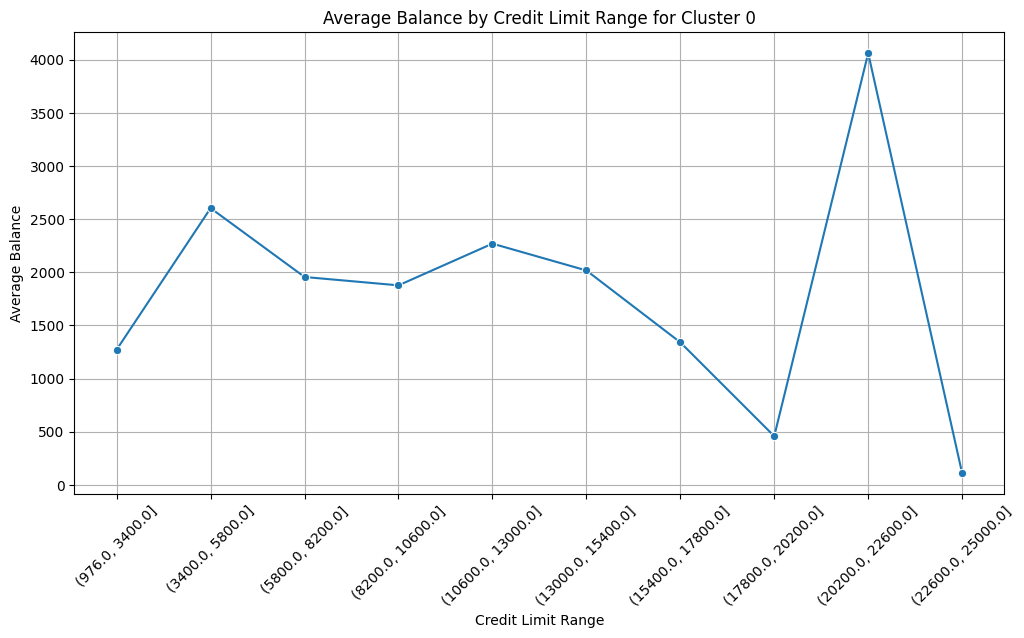

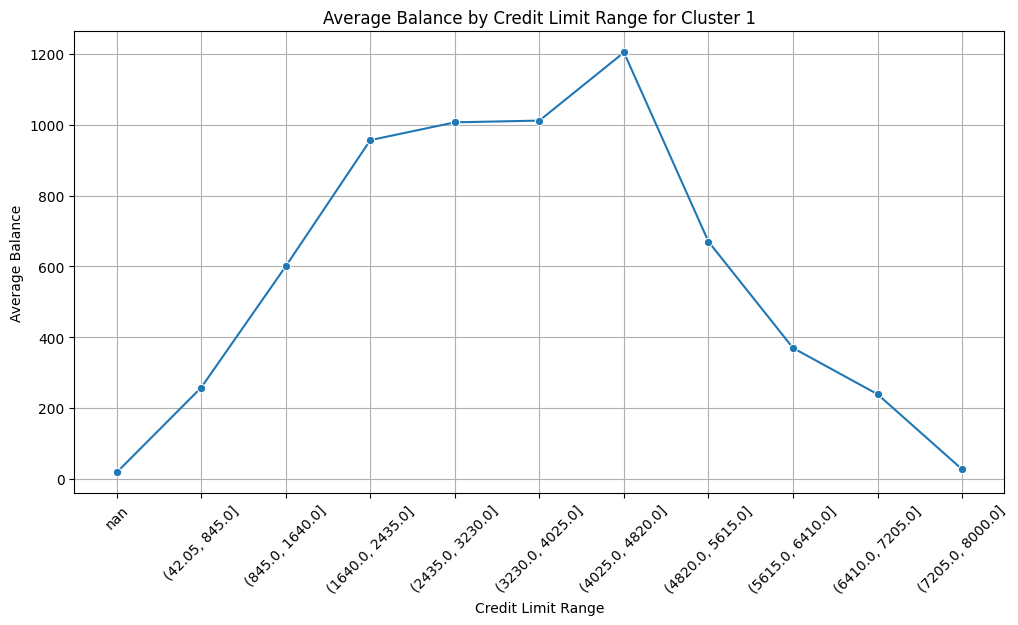

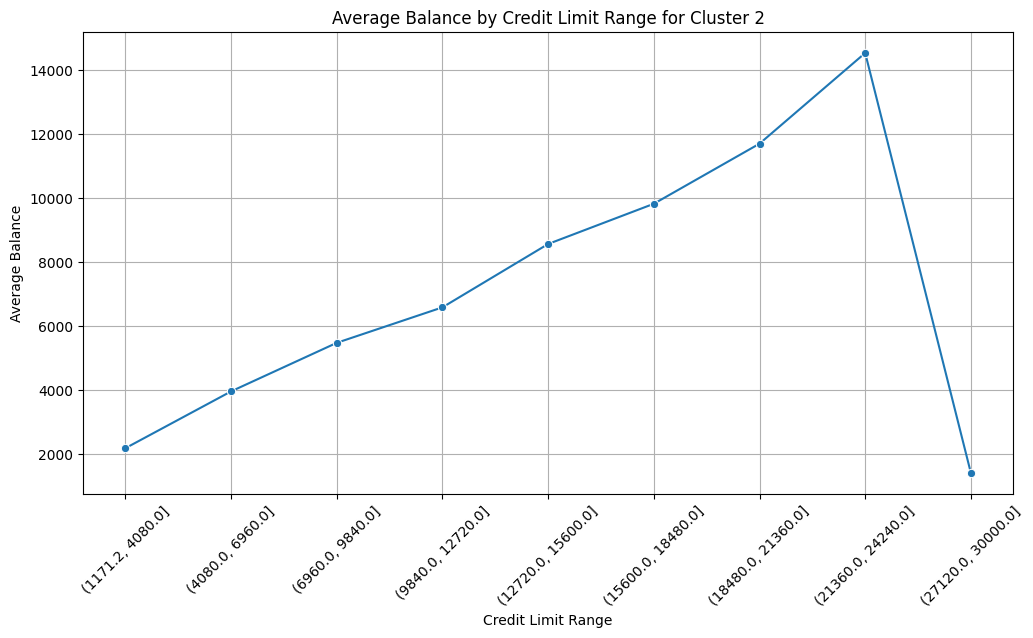

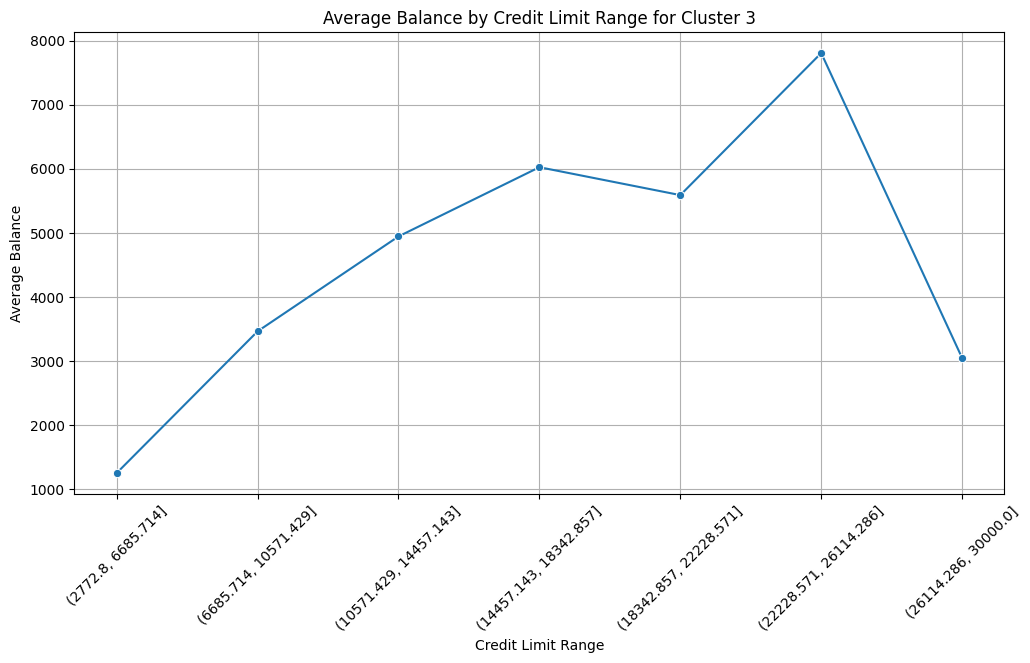

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'df' already has the 'Cluster' column from the KMeans step
if 'Cluster' not in df.columns:
    print("Please run the KMeans clustering cell first to get the 'Cluster' column.")
else:
    # Iterate through each cluster
    for cluster_id in sorted(df['Cluster'].unique()):
        cluster_df = df[df['Cluster'] == cluster_id].copy() # Create a copy to avoid SettingWithCopyWarning

        # Create bins for Credit Limit within this cluster
        # Handle cases where a cluster might have very few or no non-null credit limits
        if cluster_df['CREDIT_LIMIT'].dropna().empty:
            print(f"Cluster {cluster_id} has no valid CREDIT_LIMIT data to plot.")
            continue

        # Determine appropriate number of bins, at least 2 if possible
        num_bins = min(10, cluster_df['CREDIT_LIMIT'].nunique() // 5) or 2 # Adjust binning for small clusters
        if num_bins > 1:
             cluster_df['Credit_Limit_Bins'] = pd.cut(cluster_df['CREDIT_LIMIT'], bins=num_bins).astype(str)
        else:
             # If not enough unique values for binning, maybe just use the values directly if few
             print(f"Cluster {cluster_id} has too few unique CREDIT_LIMIT values for binning.")
             continue # Skip plotting for this cluster if binning is not feasible


        # Group by Credit Limit Bins and calculate the mean Balance
        # Handle potential NaN bins after cutting
        credit_balance_trend_cluster = cluster_df.groupby('Credit_Limit_Bins')['BALANCE'].mean().reset_index()

        # Sort the bins for a meaningful line plot, handling 'nan'
        credit_balance_trend_cluster['Sort_Key'] = credit_balance_trend_cluster['Credit_Limit_Bins'].apply(
            lambda x: float(x.split(', ')[0][1:]) if x != 'nan' else -1 # Assign a value that ensures 'nan' is sorted first or last
        )
        credit_balance_trend_cluster = credit_balance_trend_cluster.sort_values(by='Sort_Key').drop('Sort_Key', axis=1)

        # Plot the trend for the cluster
        plt.figure(figsize=(12, 6))
        sns.lineplot(x='Credit_Limit_Bins', y='BALANCE', data=credit_balance_trend_cluster, marker='o')
        plt.title(f'Average Balance by Credit Limit Range for Cluster {cluster_id}')
        plt.xlabel('Credit Limit Range')
        plt.ylabel('Average Balance')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.show()